In [205]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import re
import fnmatch
import matplotlib.pyplot as plt
from functools import reduce
from bs4 import BeautifulSoup
import requests
import osmnx as ox
from API_KEY import get_OneMap_token
import networkx as nx
import copy
import matplotlib
import matplotlib as mpl
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
from osgeo import gdal

import importlib

import helper_functions.utils as utils
import helper_functions.serviceArea
import helper_functions.amenities_dict
import helper_functions.OneMapAPI
import helper_functions.residential_attributes
import helper_functions.flood
import helper_functions.mrt_buffer
import helper_functions.drainage_work
import helper_functions.data
import helper_functions.DEM
import helper_functions.road_raising_works

importlib.reload(helper_functions.serviceArea)
importlib.reload(helper_functions.amenities_dict)
importlib.reload(helper_functions.OneMapAPI)
importlib.reload(helper_functions.residential_attributes)
importlib.reload(helper_functions.flood)
importlib.reload(helper_functions.mrt_buffer)
importlib.reload(helper_functions.drainage_work)
importlib.reload(helper_functions.data)
importlib.reload(helper_functions.DEM)
importlib.reload(helper_functions.road_raising_works)

import helper_functions.serviceArea as serviceArea
import helper_functions.amenities_dict as amenities_dict
import helper_functions.plot_utils as plot_utils
import helper_functions.OneMapAPI as OneMapAPI
import helper_functions.residential_attributes as residential_attributes
import helper_functions.flood as Flood
import helper_functions.mrt_buffer as mrt_buffer
import helper_functions.drainage_work as drainage_work
import helper_functions.data as Data
import helper_functions.DEM as DEM
import helper_functions.road_raising_works as RoadRaisingWorks

# Import road network

In [2]:
G_car = ox.load_graphml(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\V3 analysis\data\SG_car_network.graphml")

# Import planning area

Index(['Name', 'PLN_AREA_N', 'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'], dtype='object')
Index(['Name', 'SUBZONE_NO', 'SUBZONE_N', 'SUBZONE_C', 'PLN_AREA_N',
       'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'],
      dtype='object')


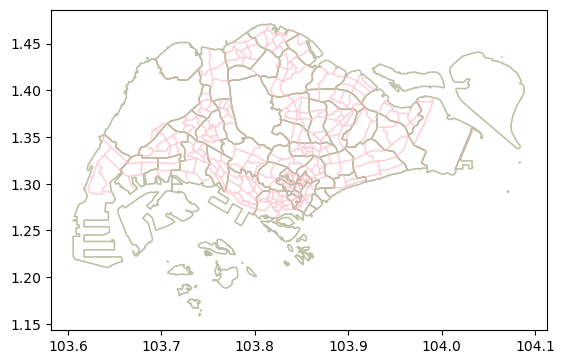

In [24]:
planningArea_shp = gpd.read_file(Data.PLANNING_AREA_FP)
subzone_shp = gpd.read_file(Data.SUBZONE_FP)
fig, ax = plt.subplots(1,1)
for shp,c in zip([planningArea_shp,subzone_shp],["green","pink"]):
    print(shp.columns)
    shp.plot(fc="none",ec=c,ax=ax,alpha=0.5)
plt.show()

### Import residential property prices

In [25]:
# residential_df = residential_attributes.get_private_residential_df(r"Exported_Data\Residential_transaction_2014_2024.csv")
residential_df = Data.get_private_residential_df(Data.PRIVATE_RESIDENTIAL_FP)
# add subzone
# spatial join with subzone
residential_df = residential_df.sjoin(subzone_shp[["SUBZONE_N","geometry"]],how="left")
# replace project names with NA with their address before unit number
residential_df["Project Name"] = residential_df.apply(lambda x: residential_attributes.get_project_name(x),axis=1)
# add nodesID for properties
residential_df['nodesID_property'] = ox.nearest_nodes(G_car,X=residential_df['LONGITUDE'], Y=residential_df['LATITUDE'])
# simplify Tenure and Completion Date
residential_df['Tenure'] = residential_df['Tenure'].astype(str).apply(lambda x: residential_attributes.get_tenure(x))
residential_df['Building Age'] = residential_attributes.get_building_age(residential_df['Completion Date'], residential_df['year'])
print("length of residential df: ", len(residential_df))
# drop index_right
residential_df = residential_df.drop(columns=["index_right"])
residential_df.head()

length of residential df:  267452


,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,X,Y,LATITUDE,LONGITUDE,year,month,geometry,SUBZONE_N,nodesID_property,Building Age
0,481 YIO CHU KANG ROAD #05-02,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,28883.630900,40954.900104,1.386656,103.841259,2014,1,POINT (103.84126 1.38666),YIO CHU KANG WEST,437138895,17.0
1,52 HUME AVENUE #01-16,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,20479.219140,37907.302875,1.359094,103.765739,2014,1,POINT (103.76574 1.35909),HILLVIEW,7495834879,12.0
2,41 BRIGHT HILL DRIVE #14-01,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New Sale,Strata,68.0,15456,...,27661.184826,37765.008907,1.357808,103.830274,2014,1,POINT (103.83027 1.35781),UPPER THOMSON,4727949662,2014.0
3,103 HILLVIEW RISE #10-11,730000,516.67,1413,2014-01-03,103 HILLVIEW RISE #10-11,New Sale,Strata,48.0,15208,...,20304.463939,38537.214606,1.364790,103.764169,2014,1,POINT (103.76417 1.36479),HILLVIEW,6540315280,2014.0
4,628 UPPER THOMSON ROAD #05-61,2518000,3035.45,830,2014-01-03,628 UPPER THOMSON ROAD #05-61,Resale,Strata,282.0,8929,...,27381.798079,40248.119710,1.380264,103.827764,2014,1,POINT (103.82776 1.38026),TAGORE,311986889,2.0


# Import and process flooding hotspot (2011 - 2024)

In [ ]:
flooding_hotspots = pd.read_csv(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\Climate Impacts in Singapore\Flooding\flooding_hotspots_2011_2024.csv")
flooding_hotspots.head()

headers = OneMapAPI.generate_OneMap_headers()
def get_flooding_hotspots(flooding_hotspots,headers,save_fp=None):
    """ Returns the matched location given a flooded location, using the OneMap API
    Args:
        flooding_hotspots (pd.DataFrame): each column corresponds to flooding locations in that particular year
        save_fp (str): file to save csv
    Returns:
        pd.DataFrame: 
    """
    hotspots = []
    for col in flooding_hotspots.columns.to_list():
        locations = flooding_hotspots[col].dropna()
        year = col.split('-')[1]
        year = year.strip()
        for l in locations:
            results = OneMapAPI.get_coordinates_from_location(l,headers=headers)
            # response_found, searchVal, latitude, longitude = flood_utils.get_coordinates_from_location(l)
            # get first result
            try:
                result = results[0]

                hotspots.append({'year':year,
                                'flooded_location':l,
                                'responses_found':len(results), 
                                'matched_location':result['SEARCHVAL'], 
                                'latitude':result['LATITUDE'], 
                                'longitude':result['LONGITUDE']})
            except:
                print(l)
    df = pd.DataFrame(hotspots)
    df = df.sort_values(by=['flooded_location'])
    if save_fp is not None and os.path.exists(os.path.dirname(save_fp)):
        df.to_csv(save_fp,index=False)
    
    return df.dropna(subset=['flooded_location'])

get_flooding_hotspots(flooding_hotspots, headers,
                      save_fp = r"Data\flooding_hotspots_2011_2024.csv")


# Import flooding hotspot

length of edges:  288
length of edges:  288


C:\Users\hypak\AppData\Local\Temp\ipykernel_16192\4183649583.py:17: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  flooding_hotspot.to_file(r"Data\flooding_hotspots_2011_2024.shp",driver="ESRI Shapefile")
c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'flooded_location' to 'flooded_lo'
  ogr_write(
c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'responses_found' to 'responses_'
  ogr_write(
c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'matched_location' to 'matched_lo'
  ogr_write(


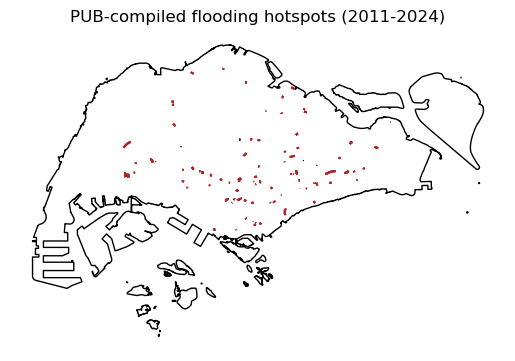

In [73]:
# flooding_hotspot = pd.read_csv(r"Data\flooding_hotspots.csv")
flooding_hotspot = pd.read_csv(r"Data\flooding_hotspots_2011_2024.csv")

flooding_hotspot
G_edges = ox.graph_to_gdfs(G_car, edges=True,nodes=False)
flooding_hotspot_edges = ox.nearest_edges(G_car,flooding_hotspot['longitude'],flooding_hotspot['latitude'])
print("length of edges: ", len(flooding_hotspot_edges))
flooding_hotspot_edges = G_edges.loc[flooding_hotspot_edges]
print("length of edges: ", len(flooding_hotspot_edges))
# flooding_hotspot['geometry'] = flooding_hotspot_edges['geometry'].to_list()
flooding_hotspot = gpd.GeoDataFrame(data=flooding_hotspot,geometry=flooding_hotspot_edges['geometry'].to_list(),crs=planningArea_shp.crs)
ax = gpd.GeoSeries(planningArea_shp.union_all()).plot(fc="none",ec="k")
flooding_hotspot.plot(ax=ax,ec="firebrick")
ax.set_title("PUB-compiled flooding hotspots (2011-2024)")
ax.axis('off')
plt.savefig(r"Exported_Data\exported_figures\PUB_compiled_flooding_hotspot.svg",bbox_inches='tight')
flooding_hotspot.to_file(r"Data\flooding_hotspots_2011_2024.shp",driver="ESRI Shapefile")

# Import DEM
- FABDEM (30m spatial resolution)

To check if higher elevation has lower flood risk, and also fetches higher property prices

In [6]:
SG_DEM = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\FABDEM_SG_30m\FABDEM_SG_30m_Clipped.tif"
SG_DEM_raster = gdal.Open(SG_DEM)
print("Projection is {}".format(SG_DEM_raster.GetProjection()))
# get geotransform
geotransform_SG_DEM_raster = SG_DEM_raster.GetGeoTransform()

band = SG_DEM_raster.GetRasterBand(1)
print("Band Type={}".format(gdal.GetDataTypeName(band.DataType)))

min_ = band.GetMinimum()
max_ = band.GetMaximum()
if not min_ or not max_:
    (min_,max_) = band.ComputeRasterMinMax(True)
print("Min={:.3f}, Max={:.3f}".format(min_,max_))

# read as array
SG_DEM_raster_arr = np.array(SG_DEM_raster.GetRasterBand(1).ReadAsArray())

def get_coords(dx,dy, geotransform):
    """" get coordinate with any array index
    Args:
        dx (int): column pixel from the origin (upper left corner)
        dy (int): row pixel from the origin (upper left corner)
    """
    # origin
    px = geotransform[0]
    py = geotransform[3]
    # pixel size
    rx = geotransform[1]
    ry = geotransform[5]
    x = dx*rx + px
    y = dy*ry + py
    return y,x

def get_DEM_value(lon,lat,geotransform):
    """
    Returns:
        dx (int): column pixel from the origin (upper left corner)
        dy (int): row pixel from the origin (upper left corner)
    """
    # origin
    px = geotransform[0]
    py = geotransform[3]
    # pixel size
    rx = geotransform[1]
    ry = geotransform[5]
    dx = (lon -px)/rx
    dy = (lat - py)/ry
    return round(dx), round(dy)

# bukit timah elevation validation (163.63m)
dx, dy = get_DEM_value(103.7763750,1.3546806,geotransform_SG_DEM_raster)
SG_DEM_raster_arr[dy, dx]

Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Band Type=Float32
Min=-37.000, Max=180.180


c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


np.float32(167.37)

In [118]:
# add DEM as a column
residential_transaction_df[["LATITUDE","LONGITUDE"]].apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)#.isna().any()

0         10.650000
1         26.629999
2         19.180000
3         21.820000
4         29.610001
            ...    
267941     6.690000
267942    18.590000
267943     6.180000
267944    18.250000
267945    10.820000
Length: 267452, dtype: float32

### Areas prone to flooding under 3m high-tide levels

Text(0.5, 1.0, 'Areas prone to flooding under 3 m high tide')

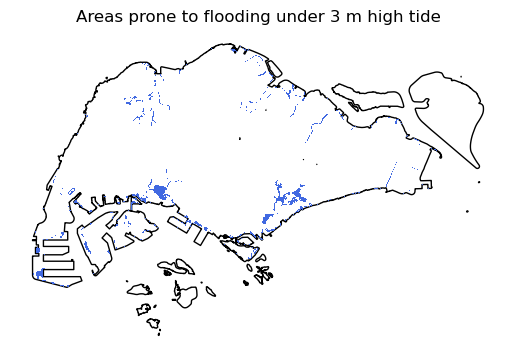

In [14]:
tide_3m = gpd.read_file(r"Data\water_depth_3m.shp")
ax = gpd.GeoDataFrame(geometry=gpd.GeoSeries(planningArea_shp.union_all())).plot(fc="none",ec="k")
gpd.GeoDataFrame(geometry=gpd.GeoSeries(tide_3m.union_all())).plot(ax=ax,fc="royalblue")
ax.axis('off')
ax.set_title("Areas prone to flooding under 3 m high tide")
# plt.savefig(os.path.join(r"Exported_Data\exported_figures","3m_high_tide.svg"),bbox_inches='tight')

In [28]:
tide_3m_polygon = tide_3m.union_all()
coastal_flood_prone = residential_transaction_df['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))
residential_transaction_df["prone_to_high_tide"] = coastal_flood_prone
residential_transaction_df

,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,POSTAL,X,Y,LATITUDE,LONGITUDE,year,month,geometry,SUBZONE_N,prone_to_high_tide
0,CASTLE GREEN,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,787056.0,28883.630900,40954.900104,1.386656,103.841259,2014,1,POINT (103.84126 1.38666),YIO CHU KANG WEST,False
1,SUMMERHILL,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,596230.0,20479.219140,37907.302875,1.359094,103.765739,2014,1,POINT (103.76574 1.35909),HILLVIEW,False
2,THOMSON THREE,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New Sale,Strata,68.0,15456,...,573893.0,27661.184826,37765.008907,1.357808,103.830274,2014,1,POINT (103.83027 1.35781),UPPER THOMSON,False
3,KINGSFORD . HILLVIEW PEAK,730000,516.67,1413,2014-01-03,103 HILLVIEW RISE #10-11,New Sale,Strata,48.0,15208,...,667982.0,20304.463939,38537.214606,1.364790,103.764169,2014,1,POINT (103.76417 1.36479),HILLVIEW,False
4,MEADOWS @ PEIRCE,2518000,3035.45,830,2014-01-03,628 UPPER THOMSON ROAD #05-61,Resale,Strata,282.0,8929,...,787131.0,27381.798079,40248.119710,1.380264,103.827764,2014,1,POINT (103.82776 1.38026),TAGORE,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267941,THE TRE VER,2300000,1097.93,2095,2025-06-18,66 POTONG PASIR AVENUE 1 #13-30,Sub Sale,Strata,102.0,22549,...,358394.0,31436.687533,35557.251883,1.337841,103.864199,2025,6,POINT (103.8642 1.33784),POTONG PASIR,False
267942,TWIN FOUNTAINS,1600000,1205.57,1327,2025-06-18,19 WOODLANDS AVENUE 6 #05-26,Resale,Strata,112.0,14286,...,738999.0,24248.043549,45896.792457,1.431349,103.799604,2025,6,POINT (103.7996 1.43135),WOODLANDS SOUTH,False
267943,BARTLEY RIDGE,890000,559.73,1590,2025-06-19,46 MOUNT VERNON ROAD #01-47,Resale,Strata,52.0,17115,...,368063.0,33357.349916,35916.628376,1.341091,103.881458,2025,6,POINT (103.88146 1.34109),JOO SENG,False
267944,THE WOODLEIGH RESIDENCES,1865000,742.72,2511,2025-06-20,21 BIDADARI PARK DRIVE #10-26,Sub Sale,Strata,69.0,27029,...,367795.0,32238.669180,35625.737646,1.338461,103.871406,2025,6,POINT (103.87141 1.33846),BIDADARI,False


In [21]:
tide_3m_union = gpd.GeoDataFrame(geometry=gpd.GeoSeries(tide_3m.union_all()),crs=planningArea_shp.crs)
residential_transaction_df.sjoin(tide_3m_union,predicate="intersects")

,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,POSTAL,X,Y,LATITUDE,LONGITUDE,year,month,geometry,SUBZONE_N,index_right
44785,CORALS AT KEPPEL BAY,6520000,2658.71,2452,2017-03-09,3 KEPPEL BAY DRIVE #03-07,New Sale,Strata,247.0,26397,...,98013.0,26107.064154,27447.181010,1.264497,103.816310,2017,3,POINT (103.81631 1.2645),MARITIME SQUARE,0
54033,CORALS AT KEPPEL BAY,7600000,2658.71,2859,2019-04-24,3 KEPPEL BAY DRIVE #02-07,Resale,Strata,247.0,30769,...,98013.0,26107.064154,27447.181010,1.264497,103.816310,2019,4,POINT (103.81631 1.2645),MARITIME SQUARE,0
59849,CORALS AT KEPPEL BAY,6900000,2658.71,2595,2020-11-25,3 KEPPEL BAY DRIVE #04-07,Resale,Strata,247.0,27935,...,98013.0,26107.064154,27447.181010,1.264497,103.816310,2020,11,POINT (103.81631 1.2645),MARITIME SQUARE,0
60789,THE REEF AT KING'S DOCK,3439270,1216.33,2828,2021-01-29,20 HARBOURFRONT AVENUE #04-48,New Sale,Strata,113.0,30436,...,98000.0,26187.067308,27406.533741,1.264129,103.817029,2021,1,POINT (103.81703 1.26413),MARITIME SQUARE,0
60790,THE REEF AT KING'S DOCK,1120757,484.38,2314,2021-01-29,20 HARBOURFRONT AVENUE #03-52,New Sale,Strata,45.0,24906,...,98000.0,26187.067308,27406.533741,1.264129,103.817029,2021,1,POINT (103.81703 1.26413),MARITIME SQUARE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232389,THE RESIDENCES AT W SINGAPORE SENTOSA COVE,5050800,2572.60,1963,2025-02-14,5 OCEAN WAY #06-21,Resale,Strata,239.0,21133,...,98369.0,29033.675772,25598.523951,1.247778,103.842606,2025,2,POINT (103.84261 1.24778),SENTOSA,0
232418,THE RESIDENCES AT W SINGAPORE SENTOSA COVE,2966700,1657.66,1790,2025-02-27,5 OCEAN WAY #03-18,Resale,Strata,154.0,19264,...,98369.0,29033.675772,25598.523951,1.247778,103.842606,2025,2,POINT (103.84261 1.24778),SENTOSA,0
232587,CAPE ROYALE,5656000,2508.01,2255,2025-04-04,15 COVE WAY #16-05,Resale,Strata,233.0,24275,...,98204.0,28697.490397,24943.664500,1.241856,103.839586,2025,4,POINT (103.83959 1.24186),SENTOSA,0
232717,THE RESIDENCES AT W SINGAPORE SENTOSA COVE,3042000,1657.66,1835,2025-05-14,5 OCEAN WAY #04-17,Resale,Strata,154.0,19753,...,98369.0,29033.675772,25598.523951,1.247778,103.842606,2025,5,POINT (103.84261 1.24778),SENTOSA,0


# Import drainage works on roads
- with a buffer of 200 m around roads

['Development of Kallang River' 'Road Raising and Drainage Works'
 'Drainage Work' 'Improvement to Roadside Drains In EUP' 'Road Raising'
 'Improvement' 'Improvement to Culvert' 'Improvement to Outlet Drain'
 'Service Road' 'Construction' 'Improvement to Roadside Drains'
 'Improvement to Roadside Drains and Watermain Replacement'
 'Proposed Drainage Scheme' 'ABC Waters Project']
S/N              int64
Location        object
Date            object
Status          object
year             int64
month            int64
work_types      object
location_1      object
locations       object
SEARCHVAL       object
BLK_NO          object
ROAD_NAME       object
BUILDING        object
ADDRESS         object
POSTAL          object
X              float64
Y              float64
LATITUDE       float64
LONGITUDE      float64
number_of_     float64
work_categ      object
u                int64
v                int64
key              int64
geometry      geometry
dtype: object
596


,S/N,Location,Date,Status,year,month,work_types,location_1,locations,SEARCHVAL,...,X,Y,LATITUDE,LONGITUDE,number_of_,work_categ,u,v,key,geometry
0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),...,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River,4684558080,5643502198,0,"POLYGON ((103.83566 1.36457, 103.83563 1.36458..."
1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,...,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works,408735646,2641677416,0,"POLYGON ((103.84634 1.32943, 103.84654 1.32967..."
2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,...,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works,2168300378,6754998201,0,"POLYGON ((103.83165 1.31215, 103.83161 1.31211..."
3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,...,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works,1268263183,1268264187,0,"POLYGON ((103.94684 1.32824, 103.94673 1.32837..."
4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,"Bedok Garden, Bedok, Southeast, Singapore, 469...",...,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works,243486752,3030270542,0,"POLYGON ((103.95411 1.32159, 103.95398 1.3215,..."


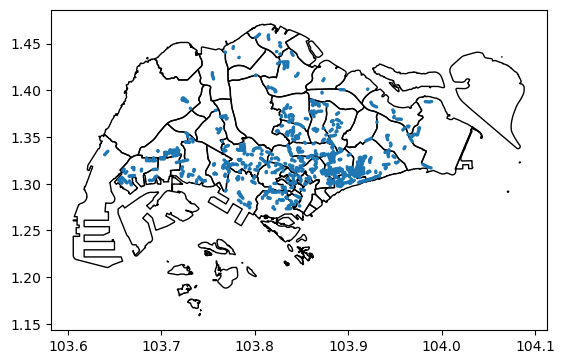

In [193]:
completed_drainage_works = gpd.read_file(r"Exported_Data\drainage_works_buffer200m.shp")
ax = planningArea_shp.plot(fc='none',ec='k')
completed_drainage_works.plot(ax=ax)
print(completed_drainage_works["work_categ"].unique())
completed_drainage_works = completed_drainage_works.rename(columns={"Year":"year","Month":"month"})
print(completed_drainage_works.dtypes)
print(len(completed_drainage_works))
# work_categ has no NAs but ROAD_NAME column has NAs
completed_drainage_works.head()

# Merge drainage works with residential transaction

In [288]:
residential_drainage = residential_transaction_df.sjoin(completed_drainage_works[["work_categ","year","month","ROAD_NAME","geometry"]],how="left",
                                                        rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])
residential_drainage = residential_drainage.sort_values(by=["Sale_Date","year","month"])
print(len(residential_drainage))
# remove duplicated index
residential_drainage = residential_drainage[~residential_drainage.index.duplicated(keep="first")]
print(len(residential_drainage))
print(f"Number of NAs in work_categ: {residential_drainage["work_categ"].isna().sum()}")
print(f"Number of NAs in ROAD_NAME_drainage: {residential_drainage["ROAD_NAME_drainage"].isna().sum()}")
residential_drainage = residential_drainage.drop(columns=['index_drainage'])
residential_drainage

267554
267452
Number of NAs in work_categ: 266878
Number of NAs in ROAD_NAME_drainage: 267057


,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,POSTAL,X,Y,LATITUDE,LONGITUDE,year,month,geometry,work_categ,ROAD_NAME_drainage
111375,THE WATERSIDE,2000000,2142.04,934,2014-01-01,11 TANJONG RHU ROAD #18-02,Resale,Strata,199.0,10050,...,436896.0,33503.361368,31008.607863,1.296705,103.882769,2014,1,POINT (103.88277 1.2967),NaN,NaN
0,CASTLE GREEN,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,787056.0,28883.630900,40954.900104,1.386656,103.841259,2014,1,POINT (103.84126 1.38666),NaN,NaN
1,SUMMERHILL,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,596230.0,20479.219140,37907.302875,1.359094,103.765739,2014,1,POINT (103.76574 1.35909),NaN,NaN
2,THOMSON THREE,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New Sale,Strata,68.0,15456,...,573893.0,27661.184826,37765.008907,1.357808,103.830274,2014,1,POINT (103.83027 1.35781),NaN,NaN
20475,BLUE HORIZON,1330000,1216.33,1093,2014-01-02,27 WEST COAST CRESCENT #24-23,Resale,Strata,113.0,11770,...,128048.0,20373.536810,31096.807133,1.297502,103.764791,2014,1,POINT (103.76479 1.2975),NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153145,GRAND DUNMAN,3284000,1291.68,2542,2025-06-21,6 DUNMAN ROAD #01-17,New Sale,Strata,120.0,27367,...,439395.0,34382.377061,32298.376712,1.308369,103.890667,2025,6,POINT (103.89067 1.30837),NaN,NaN
80885,PINETREE HILL,3214000,1216.33,2642,2025-06-22,32 PINE GROVE #22-09,New Sale,Strata,113.0,28442,...,598442.0,21613.042222,33614.295829,1.320270,103.775928,2025,6,POINT (103.77593 1.32027),NaN,NaN
80886,NAVA GROVE,2903700,1108.69,2619,2025-06-22,40 PINE GROVE #24-10,New Sale,Strata,103.0,28191,...,597775.0,21521.152286,33552.534129,1.319711,103.775103,2025,6,POINT (103.7751 1.31971),NaN,NaN
168511,HILL HOUSE,1400000,430.56,3252,2025-06-22,11 INSTITUTION HILL #09-08,New Sale,Strata,40.0,35000,...,239666.0,28700.262278,30852.885352,1.295297,103.839611,2025,6,POINT (103.83961 1.2953),NaN,NaN


In [287]:
# add drainage related columns
# drainage_work_nearby (is this property located in the area served by a drainage improvement)
def add_drainage_work_nearby(df):
    """                                 
    is this property located in the area served by a drainage improvement
    """
    df_copy = copy.deepcopy(df)
    df_copy["drainage_work_nearby"] = df["work_categ"].notna()
    return df_copy

def add_drainage_completion_date(df):
    """                              
    (NA if no drainage work applies)
    """
    df_copy = copy.deepcopy(df)
    df_copy["drainage_completion_date"] = pd.Series("Never treated",index=df_copy.index).mask(df["work_categ"].notna(),"Completed")
    return df_copy

def get_drainage_period(df_subset, construction_period=6):
    """ 
    Args:
        df_subset (pd.DataFrame) refers to the specific project name that have/will undergo(ne) a specific drainage work
        e.g. residential_drainage[residential_drainage["Project Name"] == "ASCENTIA SKY]
        construction_period (float): number of months that the drainage work will last for
    Returns:
        pd.Series
    """
    # make sure the df_subset is sorted by date
    df_subset = df_subset.sort_values(by="Sale_Date")
    # identify rows which coincides with drainage works
    drainage_entries = df_subset["work_categ"].notna()
    if drainage_entries.sum() > 0:
        # create drainage period series
        drainage_period = pd.Series(np.nan,index=df_subset.index,dtype="string")
        drainage_period.loc[drainage_entries] = "construction"
        # shift drainage completion down by one to indicate after completion
        after_completion = drainage_period.shift(1)
        drainage_period.loc[after_completion=="construction"] = "after"
        # get drainage_date 
        # cannot use this because it will also pick up dates that are not drainage completion dates
        # drainage_date = pd.to_datetime(df_subset["year"].astype(str) + '-' + df_subset["month"].astype(str).str.zfill(2)+ '-28')
        # to get drainage completion date from ROAD_NAME_drainage, rest is na
        drainage_completion = pd.Series(np.nan,index=df_subset.index,dtype='datetime64[ns]')
        drainage_completion_date = df_subset.loc[drainage_entries,["year","month"]]
        drainage_completion.loc[drainage_entries] = pd.to_datetime(drainage_completion_date["year"].astype(str) + '-' + drainage_completion_date["month"].astype(str).str.zfill(2)+ '-28')
        
        # backward fill drainage completion date so that NAs are filled with drainage completion date
        drainage_completion = drainage_completion.bfill()
        # get drainage construction date e.g. 6 months before completion date
        drainage_construction_start = drainage_completion - pd.DateOffset(months=construction_period)
        # get the first drainage construction start date
        first_construction_date = drainage_construction_start.values[0]

        # identify rows before construction start date
        drainage_period.loc[df_subset["Sale_Date"] < first_construction_date] = "before" 
        # assign as construction if sale date is between drainage completion and construction start
        drainage_period.loc[(df_subset["Sale_Date"]>=drainage_construction_start) & (df_subset["Sale_Date"]<drainage_completion)] = "construction"
        # assign as after if sale date is after drainage completion
        # forward fill NA with after
        drainage_period = drainage_period.ffill()
        return drainage_period
    
    else:
        # if work categ rows are all NAs, it means no drainage work has been implemented (untreated), input "never"
        return pd.Series("never",index=df_subset.index)
    
def get_work_categ(df_subset):
    """ 
    Args:
        df_subset (pd.DataFrame) refers to the specific project name that have/will undergo(ne) a specific drainage work
        e.g. residential_drainage[residential_drainage["Project Name"] == "ASCENTIA SKY]
        df after applying get_drainage_period
    Returns:
        pd.Series
    """
    # identify rows which coincides with drainage works
    drainage_entries = df_subset["work_categ"].notna()
    if drainage_entries.sum() > 0:
        # make sure the df_subset is sorted by date
        df_subset = df_subset.sort_values(by="Sale_Date")
        work_categ = df_subset['work_categ'].bfill()
        # create mask for rows with "after"
        mask = (df_subset["drainage_period"]=="after")|(df_subset["drainage_period"]=="before")
        work_categ.loc[mask] = np.nan
        work_categ = work_categ.ffill().fillna(value="none") # so as to fill the rows that are "after", and fill "before" rows with "none"
        return work_categ
    else:
        return pd.Series("none",index=df_subset.index)


def add_drainage_period(df,construction_period=6):
    """                             
    assign before, construction, after, never based on transaction_date and drainage work_date
    """
    df_copy = copy.deepcopy(df)
    df_copy["drainage_period"] = pd.Series(np.nan,index=df_copy.index,dtype="string")
    # get drainage period for each project name with at least one drainage work
    drainage_period = df_copy.groupby(["Project Name"]).apply(lambda x: get_drainage_period(x,construction_period=construction_period)).reset_index(level=[0],name="drainage_period")
    df_copy.loc[drainage_period.index,"drainage_period"] = drainage_period["drainage_period"]
    # get work_categ for each project name with at least one drainage work
    work_categ = df_copy.groupby(["Project Name"]).apply(lambda x: get_work_categ(x)).reset_index(level=[0],name="work_categ")
    df_copy.loc[work_categ.index,"work_categ"] = work_categ["work_categ"]
    
    return df_copy

# add_drainage_work_nearby(residential_drainage)
# x = add_drainage_completion_date(residential_drainage)
df_test = add_drainage_period(residential_drainage)
# get_drainage_period(df_test, construction_period=6)
# df_test["drainage_period"] = get_drainage_period(df_test, construction_period=6)
df_test

C:\Users\hypak\AppData\Local\Temp\ipykernel_1220\2038850932.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  drainage_period = df_copy.groupby(["Project Name"]).apply(lambda x: get_drainage_period(x,construction_period=construction_period)).reset_index(level=[0],name="drainage_period")
C:\Users\hypak\AppData\Local\Temp\ipykernel_1220\2038850932.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  work_

,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,Y,LATITUDE,LONGITUDE,year,month,geometry,index_drainage,work_categ,ROAD_NAME_drainage,drainage_period
111375,THE WATERSIDE,2000000,2142.04,934,2014-01-01,11 TANJONG RHU ROAD #18-02,Resale,Strata,199.0,10050,...,31008.607863,1.296705,103.882769,2014,1,POINT (103.88277 1.2967),NaN,none,NaN,never
0,CASTLE GREEN,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,40954.900104,1.386656,103.841259,2014,1,POINT (103.84126 1.38666),NaN,none,NaN,never
1,SUMMERHILL,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,37907.302875,1.359094,103.765739,2014,1,POINT (103.76574 1.35909),NaN,none,NaN,never
2,THOMSON THREE,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New Sale,Strata,68.0,15456,...,37765.008907,1.357808,103.830274,2014,1,POINT (103.83027 1.35781),NaN,none,NaN,never
20475,BLUE HORIZON,1330000,1216.33,1093,2014-01-02,27 WEST COAST CRESCENT #24-23,Resale,Strata,113.0,11770,...,31096.807133,1.297502,103.764791,2014,1,POINT (103.76479 1.2975),NaN,none,NaN,never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153145,GRAND DUNMAN,3284000,1291.68,2542,2025-06-21,6 DUNMAN ROAD #01-17,New Sale,Strata,120.0,27367,...,32298.376712,1.308369,103.890667,2025,6,POINT (103.89067 1.30837),NaN,none,NaN,never
80885,PINETREE HILL,3214000,1216.33,2642,2025-06-22,32 PINE GROVE #22-09,New Sale,Strata,113.0,28442,...,33614.295829,1.320270,103.775928,2025,6,POINT (103.77593 1.32027),NaN,none,NaN,never
80886,NAVA GROVE,2903700,1108.69,2619,2025-06-22,40 PINE GROVE #24-10,New Sale,Strata,103.0,28191,...,33552.534129,1.319711,103.775103,2025,6,POINT (103.7751 1.31971),NaN,none,NaN,never
168511,HILL HOUSE,1400000,430.56,3252,2025-06-22,11 INSTITUTION HILL #09-08,New Sale,Strata,40.0,35000,...,30852.885352,1.295297,103.839611,2025,6,POINT (103.83961 1.2953),NaN,none,NaN,never


### Validation
- to check if drainage type and construction period corresponds with the start and completion date
- handling of multiple drainage types for the same project name

In [282]:
x = df_test[df_test["Project Name"]=="6 DERBYSHIRE"][["Sale_Date","work_categ","drainage_period"]].iloc[20:40,:]
residential_drainage[residential_drainage["Project Name"]=="# 1 LOFT"][["Project Name","work_categ"]].sort_index().head()
residential_drainage[["Project Name","work_categ"]].dropna().drop_duplicates().sort_values(by="Project Name")
x = residential_drainage[residential_drainage["Project Name"]=="6 DERBYSHIRE"][["Sale_Date","work_categ"]].sort_values(by="Sale_Date")
x[x["work_categ"].notna()]
x = residential_drainage.groupby(["Project Name"]).apply(lambda x: get_drainage_period(x)).reset_index(level=[0],name="drainage_period")
# residential_drainage.loc[x.index,:]
x[x["Project Name"]=="COTE D'AZUR"]
x = residential_drainage.groupby(["Project Name"])["work_categ"].apply(lambda x:x.bfill().ffill()).reset_index(level=[0])
df_test.loc[x.index,"work_categ"] = x["work_categ"]
df_test[df_test["Project Name"]=='# 1 LOFT']
def add_drainage_period():
    x = pd.Series(np.nan,index=residential_drainage.index[:10])
    t = pd.Series(np.nan,index=residential_drainage.index[:10])
    drainage_type = pd.Series(np.nan,index=residential_drainage.index[:10],dtype="string")
    t.iloc[[3,7]] = ["2012-05-07","2015-07-05"]
    drainage_type.iloc[[3,7]] = ["road raising", "drainage improvement"]
    t1 = pd.to_datetime(pd.Series(["2012-02-07","2012-03-07","2012-04-07","2012-05-07","2012-06-07",
                                "2015-05-05","2015-06-05","2015-07-05","2015-08-05","2015-09-05"],index=residential_drainage.index[:10]))
    t = pd.to_datetime(t)
    x.iloc[[3,7]] = "construction"
    # print(x)
    # x.ffill().bfill()
    df = pd.DataFrame({'sale_date':t1,'drainage_period':x,'drainage_date':t,'drainage_type':drainage_type})
    # where df represents a specific project name and the construction works
    # shift drainage_period down by one
    after = df['drainage_period'].shift(1)
    df.loc[after=="construction",'drainage_period'] = "after"
    # drainage completion date
    drainage_completion = df["drainage_date"].bfill()
    # drainage_construction_start
    drainage_construction_start = drainage_completion - pd.DateOffset(months=1)
    # get the first drainage construction start date
    first_construction_date = drainage_construction_start.values[0]
    df.loc[df["sale_date"] < first_construction_date,"drainage_period"] = "before"
    # assign as construction if sale date is between drainage completion and construction start
    df.loc[(df["sale_date"]>=drainage_construction_start) & (df["sale_date"]<drainage_completion) ,"drainage_period"] = "construction"
    # assign as after if sale date is after drainage completion
    # forward fill NA with after
    df['drainage_period'] = df['drainage_period'].ffill()
    # update work category
    df['work_categ'] = df['drainage_type'].bfill()
    # create mask for rows with "after"
    mask = (df["drainage_period"]=="after")|(df["drainage_period"]=="before")
    df.loc[mask,"work_categ"] = np.nan
    df["work_categ"] = df["work_categ"].ffill()
    return df
add_drainage_period()

def test(construction_period=6):
    x = residential_drainage.copy()#[~residential_drainage["work_categ"].isna()]
    x = {k: df for k, df in x.groupby(["work_categ","Project Name"])}
    print(list(x))
    y = x[('Drainage Work', '# 1 LOFT')]
    z = residential_drainage[residential_drainage["Project Name"] == list(x)[0][1]]
    drainage_completion = pd.Series(np.nan,index=z.index,dtype='datetime64[ns]')
    drainage_entries = z["work_categ"].notna()
    drainage_completion_date = z.loc[drainage_entries,["year","month"]]
    drainage_completion.loc[drainage_entries] = pd.to_datetime(drainage_completion_date["year"].astype(str) + '-' + drainage_completion_date["month"].astype(str).str.zfill(2)+ '-28')
    drainage_construction_start = drainage_completion - pd.DateOffset(months=construction_period)
    return drainage_construction_start[drainage_construction_start.notna()]

test()

C:\Users\hypak\AppData\Local\Temp\ipykernel_1220\1301724109.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['2012-05-07', '2015-07-05']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  t.iloc[[3,7]] = ["2012-05-07","2015-07-05"]
C:\Users\hypak\AppData\Local\Temp\ipykernel_1220\1301724109.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'construction' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  x.iloc[[3,7]] = "construction"


,sale_date,drainage_period,drainage_date,drainage_type,work_categ
111375,2012-02-07,before,NaT,<NA>,<NA>
0,2012-03-07,before,NaT,<NA>,<NA>
1,2012-04-07,construction,NaT,<NA>,road raising
2,2012-05-07,construction,2012-05-07,road raising,road raising
20475,2012-06-07,after,NaT,<NA>,road raising
36378,2015-05-05,after,NaT,<NA>,road raising
36379,2015-06-05,construction,NaT,<NA>,drainage improvement
36380,2015-07-05,construction,2015-07-05,drainage improvement,drainage improvement
36381,2015-08-05,after,NaT,<NA>,drainage improvement
36382,2015-09-05,after,NaT,<NA>,drainage improvement


# Analysis

In [175]:
drainage_works_df = Data.get_drainage_works_df(Data.DRAINAGE_WORKS_FP)
print(drainage_works_df.columns)
drainage_works_df

Index(['S/N', 'Location', 'Drainage_Date', 'Status', 'year', 'month',
       'work_types', 'location', 'locations', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'number_of_searches', 'work_categories'],
      dtype='object')


,S/N,Location,Drainage_Date,Status,year,month,work_types,location,locations,SEARCHVAL,...,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories
0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),...,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River
1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,...,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works
2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,...,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works
3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,...,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works
4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,"Bedok Garden, Bedok, Southeast, Singapore, 469...",...,NaN,NaN,NaN,NaN,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,436,ABC Waters Project @ Jurong Canal,1/10/2023,Completed,2023,10,ABC Waters Project,Jurong Canal,Jurong Canal,JURONG CANAL DRIVE,...,JURONG CANAL DRIVE,NIL,JURONG CANAL DRIVE,NIL,16303.58721,37042.24305,1.351269,103.728219,1.0,ABC Waters Project
592,437,Improvement to Roadside Drains and Watermain R...,1/12/2023,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Aljunied park,ALJUNIED PARK,...,NIL,ALJUNIED PARK,ALJUNIED PARK,NIL,33185.87141,34630.63258,1.329461,103.879916,1.0,Improvement to Roadside Drains and Watermain R...
593,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane,KRAMAT LANE,...,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.64591,31481.20325,1.300979,103.842274,1.0,Road Raising
594,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road,CAVENAGH ROAD,...,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.50445,32268.65509,1.308094,103.842139,1.0,Road Raising


### Road raising + buffer

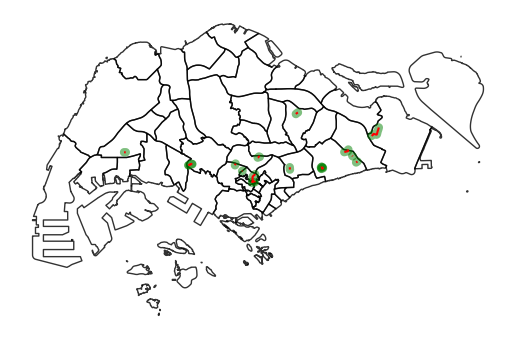

In [216]:
# overlay roads + buffer
ax = planningArea_shp.plot(fc="None",ec="k",alpha=0.8)
road_raising_works_buffer_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist=None)
road_raising_works_buffer_df.plot(ax=ax,color="red")
road_raising_works_buffer_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist=500)
road_raising_works_buffer_df.plot(ax=ax,color="green",alpha=0.5)

ax.axis('off')
plt.savefig(os.path.join(r"Exported_Data\exported_figures\RoadRaising",f"RoadRaising_buffer500m_SG.svg"))
plt.show()

### Road raising + downstream road network + buffer

(np.float64(103.58156158713254),
 np.float64(104.11262218316446),
 np.float64(1.143094894059516),
 np.float64(1.486378638658784))

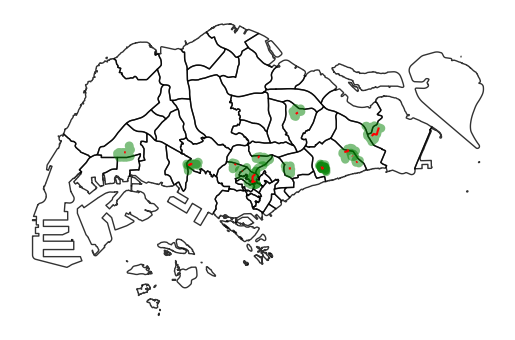

In [214]:
road_raising_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist=None)
road_raising_works_buffer_df = Data.get_road_raising_network_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                                            reverse = False, 
                                                                            depth_limit = 5,
                                                                            buffer_dist=500)

# overlay roads with downstream + buffer
ax = planningArea_shp.plot(fc="None",ec="k",alpha=0.8)
# fig, ax = plt.subplots(1,1)
road_raising_works_buffer_df.plot(ax=ax,color="green",alpha=0.5)
road_raising_df.plot(ax=ax,color="red")
ax.axis('off')

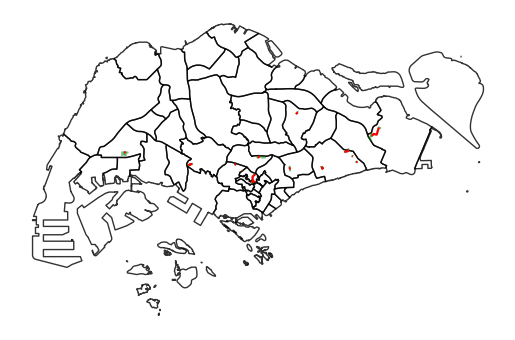

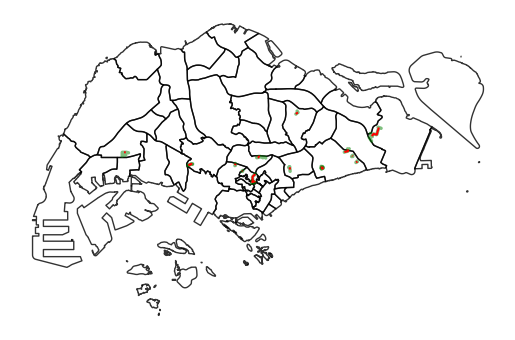

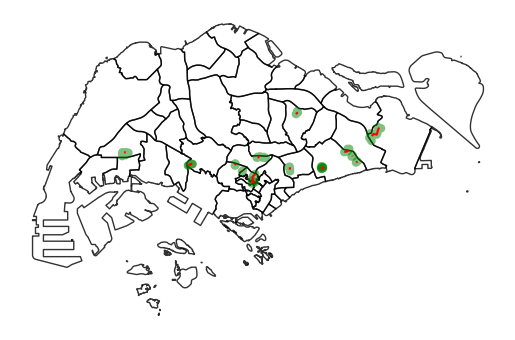

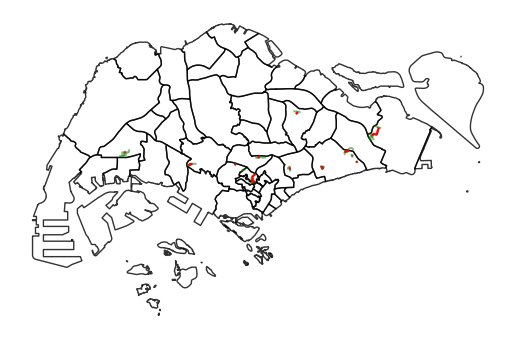

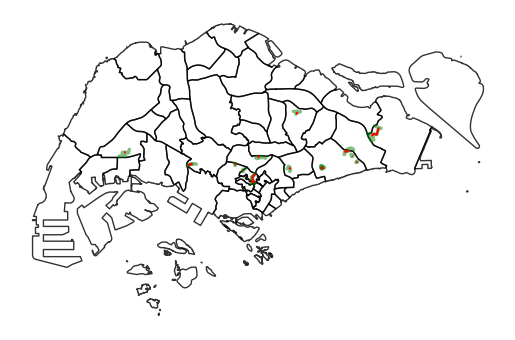

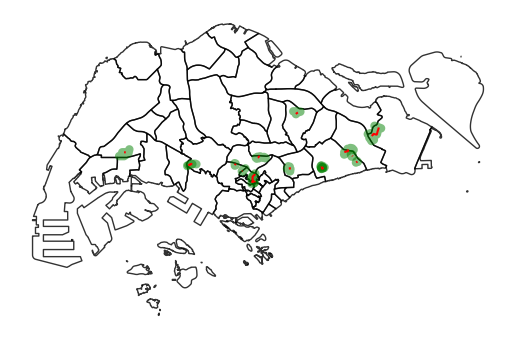

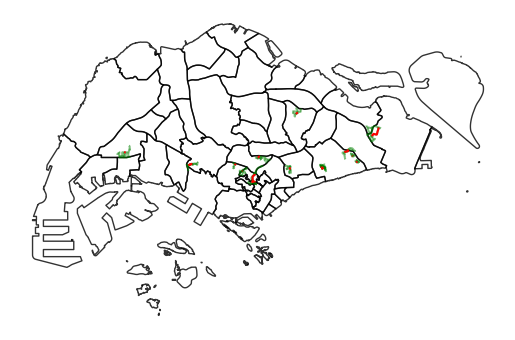

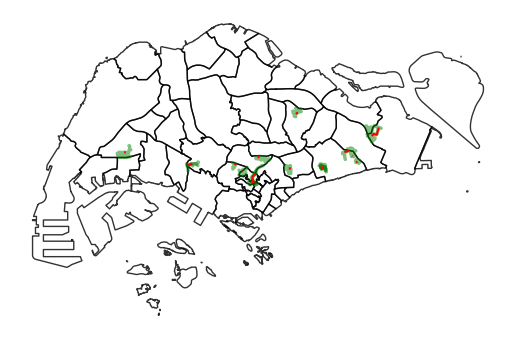

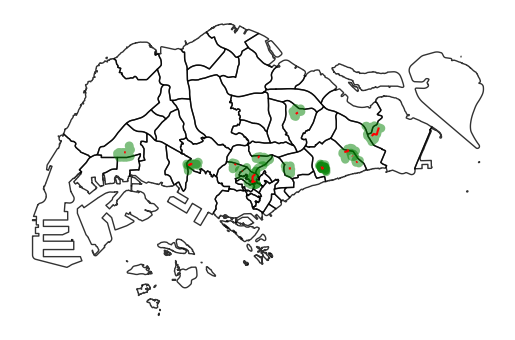

In [ ]:
for depth_limit in [1,2,5]:
    for buffer_dist in [None, 200, 500]:
        road_raising_works_buffer_df = Data.get_road_raising_network_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                                            reverse = False, 
                                                                            depth_limit = depth_limit,
                                                                            buffer_dist=buffer_dist)

        # overlay roads with downstream + buffer
        ax = planningArea_shp.plot(fc="None",ec="k",alpha=0.8)
        # fig, ax = plt.subplots(1,1)
        road_raising_works_buffer_df.plot(ax=ax,color="green",alpha=0.5)
        road_raising_df.plot(ax=ax,color="red")
        ax.axis('off')
        plt.savefig(os.path.join(r"Exported_Data\exported_figures\RoadRaising",f"downstreamRoadRaising_depth{depth_limit}_buffer{buffer_dist}m_SG.svg"))
        plt.show()
        # road_raising_works_buffer_df.head()

In [201]:
road_raising_works_buffer_df

,u,v,geometry,S/N,Location,Drainage_Date,Status,year,month,work_types,...,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories,key
0,408735646,2641677416,GEOMETRYCOLLECTION EMPTY,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NIL,AH HOOD ROAD,NIL,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising,0
1,2168300378,6754998201,GEOMETRYCOLLECTION EMPTY,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NIL,BALMORAL ROAD,NIL,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising,0
2,1268263183,1268264187,GEOMETRYCOLLECTION EMPTY,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NIL,BEDOK LANE,NIL,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising,0
3,243486752,3030270542,GEOMETRYCOLLECTION EMPTY,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NaN,NaN,NaN,NaN,NaN,1.322983,103.952932,3.0,Road Raising,0
4,3756077209,1744516916,GEOMETRYCOLLECTION EMPTY,6,Road Raising and Drainage Works at Lewis Rd,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NIL,LEWIS ROAD,NIL,26819.60407,33600.97291,1.320150,103.822712,1.0,Road Raising,0
5,256107629,593413688,GEOMETRYCOLLECTION EMPTY,15,"Road Raising Works at Frankel Walk, Frankel Dr...",1/1/2013,Completed,2013,1,Road Raising Works,...,NIL,FRANKEL WALK,NIL,37070.80638,33285.15185,1.317292,103.914825,1.0,Road Raising,0
6,245222011,245222021,GEOMETRYCOLLECTION EMPTY,15,"Road Raising Works at Frankel Walk, Frankel Dr...",1/1/2013,Completed,2013,1,Road Raising Works,...,NIL,FRANKEL DRIVE,NIL,37185.97281,33300.52489,1.317431,103.915859,1.0,Road Raising,0
7,256107635,3731233925,GEOMETRYCOLLECTION EMPTY,15,"Road Raising Works at Frankel Walk, Frankel Dr...",1/1/2013,Completed,2013,1,Road Raising Works,...,NIL,FRANKEL STREET,NIL,37173.66002,33195.55535,1.316482,103.915749,1.0,Road Raising,0
8,256107635,256107639,GEOMETRYCOLLECTION EMPTY,16,Road Raising Works at Hartley Grove,1/1/2013,Completed,2013,1,Road Raising Works,...,NIL,HARTLEY GROVE,NIL,37198.02232,33133.92303,1.315925,103.915968,1.0,Road Raising,0
9,395054088,1727076765,GEOMETRYCOLLECTION EMPTY,88,Road Raising Works at Changi North Way,1/10/2013,Completed,2013,10,Road Raising Works,...,NIL,CHANGI NORTH WAY,NIL,43762.02674,37433.45432,1.354813,103.974952,1.0,Road Raising,0


In [ ]:
# includes both drainage works on roadside and outlet drains + culvert improvement works
Data.get_drain_improvement_buffer_df(G_car, Data.DRAINAGE_WORKS_FP, buffer_dist=400)

c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:169: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drains_df['work_categories'] = "Improvement to Roadside/Outlet Drains"
c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  culvert_df['work_categories'] = "

,S/N,Location,Drainage_Date,Status,year,month,work_types,location,locations,SEARCHVAL,...,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories,u,v,key,geometry
0,10,Improvement to Roadside Drains In Estate Upgra...,1/11/2012,Completed,2012,11,Improvement to Roadside Drains In Estate Upgra...,Jalan Bunga Rampai,Jalan Bunga Rampai,JALAN BUNGA RAMPAI,...,33568.17623,35757.66191,1.339652,103.883349,1.0,Improvement to Roadside/Outlet Drains,378628547,245566400,0,"POLYGON ((103.88026 1.33601, 103.88004 1.33621..."
1,11,Improvement to Roadside Drains In Estate Upgra...,1/11/2012,Completed,2012,11,Improvement to Roadside Drains In Estate Upgra...,Phoenix,Phoenix,"Phoenix, 40, Choa Chu Kang Road, Teck Whye, Ch...",...,NaN,NaN,1.378616,103.758008,2.0,Improvement to Roadside/Outlet Drains,2145148899,2145148900,0,"POLYGON ((103.7572 1.38194, 103.75726 1.38196,..."
2,26,Improvement to Roadside Drains In Batch 5 of t...,1/5/2013,Completed,2013,5,Improvement to Roadside Drains In Batch 5 of t...,Gerald Drive,Gerald Drive,GERALD DRIVE,...,32912.49351,40725.09521,1.384580,103.877461,1.0,Improvement to Roadside/Outlet Drains,2392369426,1711536770,0,"POLYGON ((103.87484 1.38092, 103.87482 1.38093..."
3,110,Improvement to Roadside Drains In Batch 5 of t...,1/1/2014,Completed,2014,1,Improvement to Roadside Drains In Batch 5 of t...,Charlton Park,Charlton Park,CHARLTON PARK,...,33994.84181,37544.11698,1.355810,103.887186,10.0,Improvement to Roadside/Outlet Drains,1366728322,1366728360,0,"POLYGON ((103.88452 1.35811, 103.88458 1.35825..."
4,111,Improvement to Roadside Drains In Batch 5 of t...,1/1/2014,Completed,2014,1,Improvement to Roadside Drains In Batch 5 of t...,Sembawang Springs,Sembawang Springs,SEMBAWANG SPRINGS ESTATE,...,27312.64524,46684.80334,1.438475,103.827142,10.0,Improvement to Roadside/Outlet Drains,1436113713,1436113594,0,"POLYGON ((103.829 1.43558, 103.82877 1.43545, ..."
5,112,Improvement to Roadside Drains In Batch 5 of t...,1/1/2014,Completed,2014,1,Improvement to Roadside Drains In Batch 5 of t...,Kebun Bahru Villas,Kebun Bahru Villas,"Kebun Bahru, Ang Mo Kio, Singapore, North-East...",...,NaN,NaN,1.373450,103.839610,1.0,Improvement to Roadside/Outlet Drains,308944345,308940893,0,"POLYGON ((103.83875 1.3694, 103.83854 1.36938,..."
6,114,Improvement to Outlet Drain at Sin Ming Rd,1/1/2014,Completed,2014,1,Improvement to Outlet Drain,Sin Ming Rd,Sin Ming Rd,SIN MING ROAD,...,28491.70585,37546.36853,1.355832,103.837739,2.0,Improvement to Roadside/Outlet Drains,243415165,1843181719,0,"POLYGON ((103.83504 1.35827, 103.83508 1.35832..."
7,181,Improvement to Roadside Drains In Batch 6 of t...,1/11/2014,Completed,2014,11,Improvement to Roadside Drains In Batch 6 of t...,Windsor Park,Windsor Park,WINDSOR NATURE PARK,...,26632.16670,37694.02803,1.357166,103.821028,10.0,Improvement to Roadside/Outlet Drains,1318498273,3784797715,0,"POLYGON ((103.82207 1.35273, 103.82207 1.35273..."
8,187,Improvement to Roadside Drains In Batch 6 of t...,1/12/2014,Completed,2014,12,Improvement to Roadside Drains In Batch 6 of t...,Thomson Ridge,Thomson Ridge,THOMSON RIDGE,...,28170.66836,37166.05657,1.352391,103.834852,10.0,Improvement to Roadside/Outlet Drains,3987285531,4735281548,0,"POLYGON ((103.83239 1.34969, 103.8322 1.34977,..."
9,198,Improvement to Roadside Drains In Estate Upgra...,1/4/2015,Completed,2015,4,Improvement to Roadside Drains In Estate Upgra...,Jalan Mata Ayer,Jalan Mata Ayer,JALAN MATA AYER,...,26991.24977,45562.39434,1.428325,103.824254,1.0,Improvement to Roadside/Outlet Drains,2395975759,2395975757,0,"POLYGON ((103.82554 1.43194, 103.82577 1.43187..."


In [5]:
drainage_works = pd.read_csv(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\Exported_Data\drainage_works_roads_2012_2024.csv")
print("length of df: ",len(drainage_works))
drainage_works = drainage_works.dropna(subset=["LATITUDE","LONGITUDE"])
print("length of df: ",len(drainage_works))
print(drainage_works.dtypes)
# # rename similar types of drainage works
# def recategorise_drainage_works(text):
#     text = text.strip()
#     # Check if the entire string matches "drainage work(s)"
#     if re.fullmatch(r"drainage\s+works?", text, flags=re.IGNORECASE):
#         cat = "Drainage Work"
#     elif re.fullmatch(r"road\s+raising(\s+works?)?", text, flags=re.IGNORECASE):
#         cat = "Road Raising"
#     elif re.match(r"Improvement\s+to\s+Roadside\s+Drains\s+In\s+(.*)(EUP)",text, flags=re.IGNORECASE):
#         cat = 'Improvement to Roadside Drains In EUP'
#     elif re.match(r"Improvement\s+to\s+Roadside\s+Drains\s+and\s+Watermain\s+Replacement(.*)$",text, flags=re.IGNORECASE):
#         cat = "Improvement to Roadside Drains and Watermain Replacement"
#     elif re.match(r"Improvement\s+to\s+Roadside\s+Drains(.*)$",text, flags=re.IGNORECASE):
#         cat = "Improvement to Roadside Drains"
#     else:
#         cat = text==
#     return cat
# drainage_works["work_categories"] = drainage_works["work_types"].apply(lambda x: recategorise_drainage_works(x))

drainage_works#["ROAD_NAME"]

length of df:  596
length of df:  596
S/N                     int64
Location               object
Date                   object
Status                 object
Year                    int64
Month                   int64
work_types             object
location               object
locations              object
SEARCHVAL              object
BLK_NO                 object
ROAD_NAME              object
BUILDING               object
ADDRESS                object
POSTAL                 object
X                     float64
Y                     float64
LATITUDE              float64
LONGITUDE             float64
number_of_searches    float64
work_categories        object
dtype: object


,S/N,Location,Date,Status,Year,Month,work_types,location,locations,SEARCHVAL,...,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories
0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),...,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River
1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,...,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works
2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,...,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works
3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,...,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works
4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,"Bedok Garden, Bedok, Southeast, Singapore, 469...",...,NaN,NaN,NaN,NaN,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,436,ABC Waters Project @ Jurong Canal,1/10/2023,Completed,2023,10,ABC Waters Project,Jurong Canal,Jurong Canal,JURONG CANAL DRIVE,...,JURONG CANAL DRIVE,NIL,JURONG CANAL DRIVE,NIL,16303.58721,37042.24305,1.351269,103.728219,1.0,ABC Waters Project
592,437,Improvement to Roadside Drains and Watermain R...,1/12/2023,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Aljunied park,ALJUNIED PARK,...,NIL,ALJUNIED PARK,ALJUNIED PARK,NIL,33185.87141,34630.63258,1.329461,103.879916,1.0,Improvement to Roadside Drains and Watermain R...
593,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane,KRAMAT LANE,...,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.64591,31481.20325,1.300979,103.842274,1.0,Road Raising
594,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road,CAVENAGH ROAD,...,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.50445,32268.65509,1.308094,103.842139,1.0,Road Raising


In [151]:
drainage_works['work_categories'].unique()

array(['Development of Kallang River', 'Road Raising and Drainage Works',
       'Drainage Work', 'Improvement to Roadside Drains In EUP',
       'Road Raising', 'Improvement', 'Improvement to Culvert',
       'Improvement to Outlet Drain', 'Service Road', 'Construction',
       'Improvement to Roadside Drains',
       'Improvement to Roadside Drains and Watermain Replacement',
       'Proposed Drainage Scheme', 'ABC Waters Project'], dtype=object)

### Plot drainage works

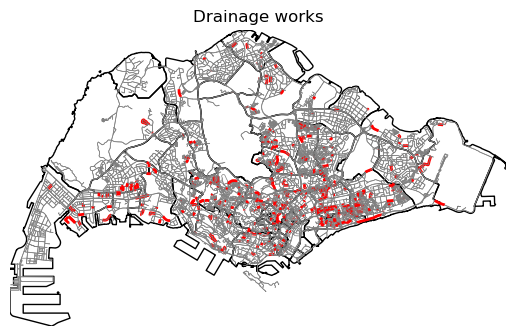

,index,S/N,Location,Date,Status,Year,Month,work_types,location,locations,...,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories,u,v,key,geometry
0,0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,...,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River,4684558080,5643502198,0,"LINESTRING (103.83684 1.36609, 103.8362 1.3663..."
1,1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,...,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works,408735646,2641677416,0,"LINESTRING (103.84899 1.32839, 103.84893 1.328..."
2,2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,...,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works,2168300378,6754998201,0,"LINESTRING (103.83054 1.31357, 103.83043 1.313..."
3,3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,...,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works,1268263183,1268264187,0,"LINESTRING (103.94847 1.32906, 103.94825 1.329..."
4,4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,...,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works,243486752,3030270542,0,"LINESTRING (103.95356 1.32342, 103.95306 1.323..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,591,436,ABC Waters Project @ Jurong Canal,1/10/2023,Completed,2023,10,ABC Waters Project,Jurong Canal,Jurong Canal,...,16303.58721,37042.24305,1.351269,103.728219,1.0,ABC Waters Project,4604170412,139672081,0,"LINESTRING (103.7282 1.35027, 103.7282 1.35073..."
592,592,437,Improvement to Roadside Drains and Watermain R...,1/12/2023,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Aljunied park,...,33185.87141,34630.63258,1.329461,103.879916,1.0,Improvement to Roadside Drains and Watermain R...,4603005311,385954195,0,"LINESTRING (103.87923 1.33073, 103.87928 1.330..."
593,593,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane,...,28996.64591,31481.20325,1.300979,103.842274,1.0,Road Raising,1363263572,26778809,0,"LINESTRING (103.84248 1.30146, 103.84245 1.301..."
594,594,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road,...,28982.50445,32268.65509,1.308094,103.842139,1.0,Road Raising,1738410982,571883466,0,"LINESTRING (103.84405 1.30984, 103.844 1.30977..."


In [22]:
planningArea_shp_mainland = planningArea_shp[~planningArea_shp["PLN_AREA_N"].str.contains("ISLAND")]
minx = planningArea_shp_mainland.bounds["minx"].min()
miny = planningArea_shp_mainland.bounds["miny"].min()
maxx = planningArea_shp_mainland.bounds["maxx"].max()
maxy = planningArea_shp_mainland.bounds["maxy"].max()

bbox = (minx, miny, maxx - 4e-4*maxx, maxy)

def identify_road_with_drainage_works(G,drainage_works, plot=True,ax=None,**kwargs):
    """                           
    Args:
        G (MultiDiGraph): graph of walking or driving network
        drainage_works (pd.DataFrame): dataframe that describes the type and location of drainage works
    Return:
        gpd: edges corresponding to drainage works location
    """
    lat = drainage_works["LATITUDE"]
    lon = drainage_works["LONGITUDE"]
    edges_drain = list(ox.nearest_edges(G,lon,lat))

    if plot:
        ec = ["red" if e in edges_drain else "grey" for e in G.edges(keys=True)]
        lw = [2 if e in edges_drain else 0.5 for e in G.edges(keys=True)]
        fig, ax = ox.plot_graph(
            G,
            ax=ax,
            node_size=0,
            node_alpha=0.8,
            edge_linewidth=lw,
            edge_color=ec,
            show=False,
            close=False,
            bgcolor="white",
            **kwargs
        )

    # get the polyline of the roads that has drainage works
    edges = ox.graph_to_gdfs(G,nodes=False,edges=True)
    edges_geometry = edges.loc[edges_drain,["geometry"]].reset_index()
    # append geometry to drainage works
    drainage_works_copy = copy.deepcopy(drainage_works)
    # reset index so the index aligns with the index of edges_geometry_df
    drainage_works_copy = drainage_works_copy.reset_index()
    drainage_works_copy[edges_geometry.columns.to_list()] = edges_geometry
    drainage_works_copy = gpd.GeoDataFrame(drainage_works_copy,geometry=drainage_works_copy["geometry"])
    return drainage_works_copy

fig, ax = plt.subplots(1,1)
planningArea_shp_mainland.plot(ax=ax,fc="None",ec="k")
drainage_works_geometry = identify_road_with_drainage_works(G_car,drainage_works,plot=True,ax=ax,bbox=bbox)
# drainage_works_geometry = identify_road_with_drainage_works(G_car,road_raising_df,plot=True,ax=ax,bbox=bbox)
ax.set_title("Drainage works")
save_fp = os.path.join(r"Exported_Data\exported_figures","road raising works.png")
# plt.savefig(save_fp, bbox_inches = 'tight')
plt.show()
drainage_works_geometry

<Axes: >

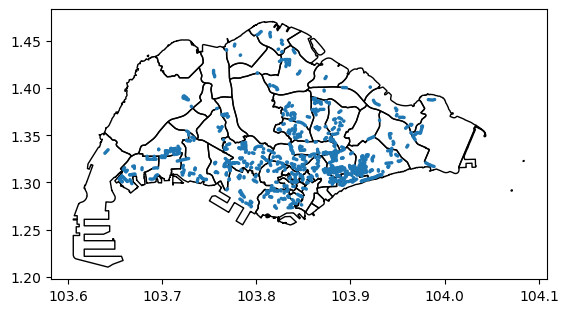

In [ ]:
def buffer_road(drainage_works_geometry,buffer=200):
    """ 
    Args:
        drainage_works_geometry (gpd): drainage works in linestring
        buffer (float): buffer around the geometry in metres
    Returns:
        polygon gpd
    """
    # project to meters UTM
    crs = drainage_works_geometry.crs
    # reproject to something that is in meters projection
    reproj_drainage_works = drainage_works_geometry.to_crs({'proj':'cea'})#.to_crs(3003)
    drainage_buffer = reproj_drainage_works.buffer(buffer)
    drainage_buffer = drainage_buffer.to_crs(crs)
    drainage_works_copy = copy.deepcopy(drainage_works_geometry)
    drainage_works_copy["geometry"] = drainage_buffer
    return drainage_works_copy

drainage_works_buffer = buffer_road(drainage_works_geometry,buffer=200)
ax = planningArea_shp_mainland.plot(fc="None",ec="k")
drainage_works_buffer.plot(ax=ax)
# drainage_works_buffer.to_file(os.path.join(r"Exported_Data","drainage_works_buffer200m.shp"),driver='ESRI Shapefile')

# Import drainage network

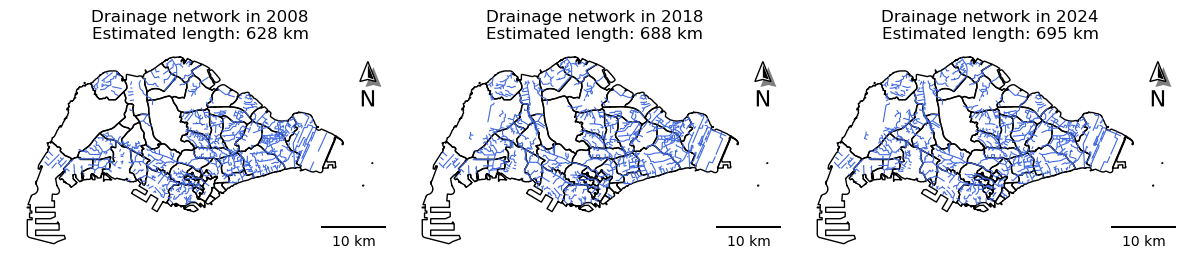

In [29]:
# drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\BlueMapShpFiles"
# drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\251027 BlueMapShpFiles"
# drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\251110 Blue Map layers"
drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\251117 Blue Map layers"
# drain_undated = "UndatedSGDrainage.shp"
drain_2008 = "2008Bluemap.shp"
drain_2018 = "251112_2018Bluemap.shp"
drain_2024 = "251117_2024Bluemap.shp"

def plot_drains(fp,planningArea,ax=None,lw=2):
    planningArea = planningArea[~planningArea['PLN_AREA_N'].str.contains("ISLAND")]
    # convert the dataset to a coordinate system which uses meters e.g. UTM work in metres
    planningArea = planningArea.to_crs(planningArea.estimate_utm_crs())
    gdf = gpd.read_file(fp)
    gdf = gdf.to_crs(planningArea.crs)
    gdf = gpd.clip(gdf,planningArea)
    # calculate total length
    drain_length = int(gdf['geometry'].length.sum()/1000) # m to km
    ax = planningArea.plot(fc="None",ec="k",ax=ax)
    gdf.plot(ax=ax,lw=lw,color="royalblue")
    # add scale
    ax.set_aspect(1)
    scalebar = ScaleBar(1, "m",location="lower right")
    # add north arrow
    north_arrow(
        ax, location="upper right", rotation={"crs": planningArea.crs, "reference": "center"},
        scale=0.2
    )
    ax.add_artist(scalebar)
    if ax is None:
        plt.show()
    
    return drain_length

fig, axes = plt.subplots(1,3,figsize=(12,6))
for ax, drain_fp,title in zip(axes.flatten(),[drain_2008,drain_2018,drain_2024],
                              ["2008","2018","2024"]):
    drain_length = plot_drains(os.path.join(drain_dir,drain_fp),planningArea_shp,ax=ax,lw=0.8)
    ax.set_title(f"Drainage network in {title}\nEstimated length: {drain_length} km")
    ax.axis('off')

save_dir = r"Exported_Data\exported_figures"
save_fp = os.path.join(save_dir,"sg_drainage_with_time.svg")
plt.tight_layout()
# plt.savefig(save_fp, bbox_inches="tight")
plt.show()

## Calculate drainage density
- calculate length of drain
- calculate area of planning area polygon
- Calculate drainage density: length of drain/planning area (km/km2)

In [ ]:
planningArea_shp_mainland = planningArea_shp[~planningArea_shp['PLN_AREA_N'].str.contains("ISLAND")]
year_drainage_density = dict()
for drain_fp,drain_year in zip([drain_2008,drain_2018,drain_2024],["2008","2018","2024"]):
    drain_shp = gpd.read_file(os.path.join(drain_dir,drain_fp))
    year_drainage_density[drain_year] = drainage_work.get_drainage_density_df(drain_shp,planningArea_shp_mainland, 
                                                             plot = False, planningArea_column="PLN_AREA_N")
year_drainage_density = pd.concat(list(year_drainage_density.values()),keys=list(year_drainage_density)).reset_index(level=[0])
year_drainage_density = year_drainage_density.rename(columns={"level_0":"year_drainage_density"})
# year_drainage_density.to_csv(os.path.join(r"Data","drainage_density_planningArea.csv"),index=False)
print("is there any NA values in drainage length: ", year_drainage_density['drainage_length_km'].isna().any())
year_drainage_density

is there any NA values in drainage length:  False


,year_drainage_density,PLN_AREA_N,drainage_length_km,area_km2,drainage_density (km/km2)
0,2008,BEDOK,39.297495,21.733905,1.808119
1,2008,BOON LAY,9.778237,8.282764,1.180552
2,2008,BUKIT BATOK,11.364697,11.140156,1.020156
3,2008,BUKIT MERAH,20.794830,14.461198,1.437974
4,2008,BUKIT PANJANG,5.170875,9.019930,0.573272
...,...,...,...,...,...
50,2024,BISHAN,14.121524,7.608112,1.856114
51,2024,ANG MO KIO,21.693473,13.942584,1.555915
52,2024,GEYLANG,24.056455,9.644787,2.494244
53,2024,PAYA LEBAR,11.536274,11.685269,0.987249


In [178]:
subzone_shp_mainland = subzone_shp[~subzone_shp['PLN_AREA_N'].str.contains("ISLAND")]
year_drainage_density = dict()
for drain_fp,drain_year in zip([drain_2008,drain_2018,drain_2024],[2008,2018,2024]):
    drain_shp = gpd.read_file(os.path.join(drain_dir,drain_fp))
    year_drainage_density[drain_year] = drainage_work.get_drainage_density_df(drain_shp,subzone_shp_mainland, 
                                                             plot = False, planningArea_column="SUBZONE_N")
year_drainage_density = pd.concat(list(year_drainage_density.values()),keys=list(year_drainage_density)).reset_index(level=[0])
year_drainage_density = year_drainage_density.rename(columns={"level_0":"year_drainage_density"})
# year_drainage_density.to_csv(os.path.join(r"Data","drainage_density_subzone.csv"),index=False)
print("is there any NA values in drainage length: ", year_drainage_density['drainage_length_km'].isna().any())
year_drainage_density

is there any NA values in drainage length:  False


,year_drainage_density,SUBZONE_N,drainage_length_km,area_km2,drainage_density (km/km2)
0,2008,DEPOT ROAD,0.141179,0.442297,0.319195
1,2008,BUKIT MERAH,1.312479,0.411723,3.187775
2,2008,CHINATOWN,0.000000,0.587223,0.000000
3,2008,PHILLIP,0.000000,0.039438,0.000000
4,2008,RAFFLES PLACE,0.000000,0.188767,0.000000
...,...,...,...,...,...
327,2024,UPPER THOMSON,5.942076,3.849507,1.543594
328,2024,SHANGRI-LA,1.433712,0.687914,2.084146
329,2024,TOWNSVILLE,0.780752,0.546394,1.428919
330,2024,MARYMOUNT,3.793594,1.964145,1.931423


### Merge residential with drainage density

In [174]:
x = year_drainage_density[year_drainage_density["SUBZONE_N"]=="TANJONG RHU"].reset_index(drop=True)
x

,year_drainage_density,SUBZONE_N,drainage_length_km,area_km2,drainage_density (km/km2)
0,2008,TANJONG RHU,2.130096,2.434593,0.874929
1,2018,TANJONG RHU,2.114527,2.434593,0.868534
2,2024,TANJONG RHU,2.106817,2.434593,0.865368


In [217]:
residential_drainage_den = residential_transaction_df.merge(year_drainage_density,how="left",left_on=["SUBZONE_N","year"],right_on=["SUBZONE_N","year_drainage_density"]).sort_values(by="Sale_Date")
# residential_drainage_den = drainage_work.add_drainage_density(residential_drainage_den,year_drainage_density)
# residential_drainage_den
residential_drainage_den.groupby(["SUBZONE_N"]).apply(lambda i: drainage_work.get_drainage_density(i,year_drainage_density)).reset_index(drop=True)

C:\Users\hypak\AppData\Local\Temp\ipykernel_26584\4135806920.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  residential_drainage_den.groupby(["SUBZONE_N"]).apply(lambda i: drainage_work.get_drainage_density(i,year_drainage_density)).reset_index(drop=True)


,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,LONGITUDE,year,month,geometry,index_right,SUBZONE_N,year_drainage_density,drainage_length_km,area_km2,drainage_density (km/km2)
0,TANGLIN VIEW,1600000,1151.75,1389,2014-03-05,152 PRINCE CHARLES CRESCENT #14-10,Resale,Strata,107.0,14953,...,103.817881,2014,3,POINT (103.81788 1.292),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
1,TANGLIN REGENCY,1430000,1044.11,1370,2014-03-13,381 TANGLIN ROAD #06-04,Resale,Strata,97.0,14742,...,103.815998,2014,3,POINT (103.816 1.29204),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
2,TANGLIN VIEW,1560000,1140.98,1367,2014-04-16,152 PRINCE CHARLES CRESCENT #10-14,Resale,Strata,106.0,14717,...,103.817881,2014,4,POINT (103.81788 1.292),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
3,TANGLIN REGENCY,1443000,1108.69,1302,2014-04-28,381 TANGLIN ROAD #11-07,Resale,Strata,103.0,14010,...,103.815998,2014,4,POINT (103.816 1.29204),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
4,TANGLIN REGENCY,1180000,850.36,1388,2014-05-12,383 TANGLIN ROAD #08-06,Resale,Strata,79.0,14937,...,103.816570,2014,5,POINT (103.81657 1.29197),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267447,WESTVILLE,2330000,1747.00,1334,2025-06-03,13 WESTWOOD ROAD,Resale,Land,162.3,14356,...,103.699206,2025,6,POINT (103.69921 1.35138),258,YUNNAN,2024.0,4.444214,2.206292,2.014336
267448,THE FLORAVALE,1375000,1248.62,1101,2025-06-03,236 WESTWOOD AVENUE #09-08,Resale,Strata,116.0,11853,...,103.696366,2025,6,POINT (103.69637 1.3506),258,YUNNAN,2024.0,4.444214,2.206292,2.014336
267449,WESTWOOD RESIDENCES,1320000,1033.34,1277,2025-06-09,180 WESTWOOD AVENUE #03-02,Resale,Strata,96.0,13750,...,103.696215,2025,6,POINT (103.69621 1.3519),258,YUNNAN,2024.0,4.444214,2.206292,2.014336
267450,WESTWOOD RESIDENCES,1440000,1033.34,1394,2025-06-12,190 WESTWOOD AVENUE #13-23,Resale,Strata,96.0,15000,...,103.697101,2025,6,POINT (103.6971 1.35254),258,YUNNAN,2024.0,4.444214,2.206292,2.014336


In [211]:

residential_drainage_den = residential_transaction_df.merge(year_drainage_density,how="left",left_on=["SUBZONE_N","year"],right_on=["SUBZONE_N","year_drainage_density"]).sort_values(by="Sale_Date")
# residential_drainage_den = drainage_work.add_drainage_density(residential_drainage_den,year_drainage_density)
# 
# mask = residential_drainage_den[["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]]<1
# residential_drainage_den.loc[mask.all(axis=1),"Sale_Date"].dt.year.min()
# residential_drainage_den.loc[mask.all(axis=1),["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]] = residential_drainage_den.loc[152817,["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]].values
# residential_drainage_den[["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]]

drainage_density_columns = ["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]
    
def get_drainage_density(df_subset,drain_df):
    """ For each subzone, fill down the same drainage density
    Args:
        df_subset (pd.DataFrame) refers to the specific subzone df_subset
        
    Returns:
        pd.Series
    """
    sale_date_column = "Sale_Date"
    noData=0
    # filter drain_df to match the subzone
    drain_df_subset = drain_df[drain_df["SUBZONE_N"]==df_subset["SUBZONE_N"].values[0]].sort_values(by="year_drainage_density").reset_index(drop=True)
    if len(drain_df_subset) > 0: # means there is drain in the SUBZONE_N
        drain_year = drain_df_subset["year_drainage_density"]
        
        df_subset = df_subset.sort_values(by=sale_date_column)
        df_subset[drainage_density_columns] = df_subset[drainage_density_columns].ffill()#.fillna(noData)
        # check if there's na
        mask = df_subset[drainage_density_columns].isna()
        if mask.all(axis=1).any():
            # obtain the years where there is NA
            year_NA = df_subset.loc[mask.all(axis=1),sale_date_column].dt.year
            # extract the drain_df where drain years are lesser than minimum transaction year
            min_year = year_NA.min()
            year_mask = drain_year < min_year
            drain_NA = drain_df_subset.loc[year_mask,drainage_density_columns]
            # use idxmax to find the latest drain year that is smaller than transaction year
            df_subset.loc[mask.all(axis=1),drainage_density_columns] = drain_NA.iloc[-1].values
            return df_subset
        else:
            return df_subset
    else: # means no drain in SUBZONE_N
        df_subset[drainage_density_columns] = df_subset[drainage_density_columns].fillna(noData)
        return df_subset

def add_drainage_density(df,drain_df,sale_date_column = "Sale_Date",noData=0):
    """                             
    add drainage density based on drainage density of specific year and to that subzone
    # TODO: create a buffer of 200 m around drainage df to see if residential areas living near to drains are more/less prone to flooding, since canal overflowing often can lead to higher flood risk
    Args:
        df (pd.DataFrame): dataframe after merging drainage density to residential df
        drain_df (pd.DataFrame): dataframe on drainage density (output from get_drainage_density_df)
        noData (float): for subzones where there are no drainage length data before 2008, assign missing data as noData (default=0)
    Returns:
        pd.DataFrame with added columns describing the stages of drainage work and drainage type
    """
    df_copy = copy.deepcopy(df)
    
    return df_copy.groupby(["SUBZONE_N"]).apply(lambda i: get_drainage_density(i,drain_df)).reset_index(level=[0])[drainage_density_columns]

# add_drainage_density(residential_drainage_den,year_drainage_density,sale_date_column = "Sale_Date",noData=0)
for k, df in residential_drainage_den.groupby("SUBZONE_N"):
    # x = residential_drainage_den[residential_drainage_den["SUBZONE_N"]=="TANJONG RHU"]
    try:
        get_drainage_density(df,year_drainage_density)
    except:
        print(k)

# x = residential_drainage_den[residential_drainage_den["SUBZONE_N"]=="SENTOSA"]
# get_drainage_density(x,year_drainage_density)
# len(year_drainage_density[year_drainage_density["SUBZONE_N"]=="SENTOSA"])

In [197]:
residential_drainage_den[residential_drainage_den["SUBZONE_N"]=="BIDADARI"]

,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,LONGITUDE,year,month,geometry,index_right,SUBZONE_N,year_drainage_density,drainage_length_km,area_km2,drainage_density (km/km2)
259792,THE WOODLEIGH RESIDENCES,1480000,721.19,2052,2018-11-10,27 BIDADARI PARK DRIVE #08-46,New Sale,Strata,67.0,22090,...,103.871540,2018,11,POINT (103.87154 1.33921),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
259793,THE WOODLEIGH RESIDENCES,1409000,645.84,2182,2018-11-10,23 BIDADARI PARK DRIVE #06-34,New Sale,Strata,60.0,23483,...,103.871424,2018,11,POINT (103.87142 1.33885),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
259794,THE WOODLEIGH RESIDENCES,1140000,592.02,1926,2018-11-10,25 BIDADARI PARK DRIVE #05-38,New Sale,Strata,55.0,20727,...,103.871225,2018,11,POINT (103.87123 1.33914),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
259795,THE WOODLEIGH RESIDENCES,1191000,592.02,2012,2018-11-10,25 BIDADARI PARK DRIVE #12-38,New Sale,Strata,55.0,21655,...,103.871225,2018,11,POINT (103.87123 1.33914),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
259797,THE WOODLEIGH RESIDENCES,1450000,721.19,2011,2018-11-10,27 BIDADARI PARK DRIVE #03-46,New Sale,Strata,67.0,21642,...,103.871540,2018,11,POINT (103.87154 1.33921),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267391,THE WOODLEIGH RESIDENCES,2700000,958.00,2818,2025-05-19,31 BIDADARI PARK DRIVE #06-57,Sub Sale,Strata,89.0,30337,...,103.872040,2025,5,POINT (103.87204 1.33915),205,BIDADARI,NaN,NaN,NaN,NaN
267403,THE WOODLEIGH RESIDENCES,1580000,699.66,2258,2025-05-26,21 BIDADARI PARK DRIVE #07-23,Sub Sale,Strata,65.0,24308,...,103.871406,2025,5,POINT (103.87141 1.33846),205,BIDADARI,NaN,NaN,NaN,NaN
267424,THE WOODLEIGH RESIDENCES,1270000,570.49,2226,2025-06-05,21 BIDADARI PARK DRIVE #03-22,Sub Sale,Strata,53.0,23962,...,103.871406,2025,6,POINT (103.87141 1.33846),205,BIDADARI,NaN,NaN,NaN,NaN
267421,THE WOODLEIGH RESIDENCES,2430000,958.00,2537,2025-06-05,27 BIDADARI PARK DRIVE #04-48,Sub Sale,Strata,89.0,27303,...,103.871540,2025,6,POINT (103.87154 1.33921),205,BIDADARI,NaN,NaN,NaN,NaN


Import hydrographic

<Axes: >

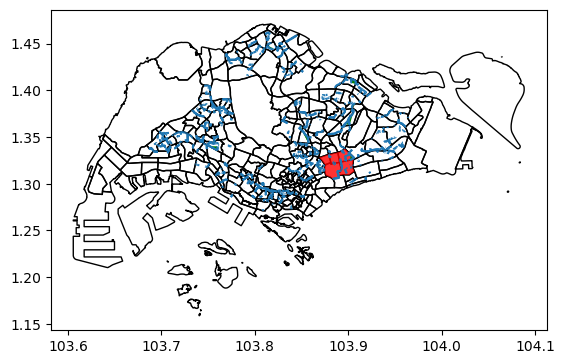

In [48]:
hydrographic = gpd.read_file(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\SG_HDB_DRAIN_OUTLINE_L.shp")
hydrographic = hydrographic.to_crs(subzone_shp.crs)
ax = subzone_shp.plot(fc="none",ec="k")
planningArea_shp[planningArea_shp["PLN_AREA_N"]=="GEYLANG"].plot(ax=ax,fc="red",alpha=0.8)
hydrographic.plot(ax=ax)

Calculate drainage difference across the years

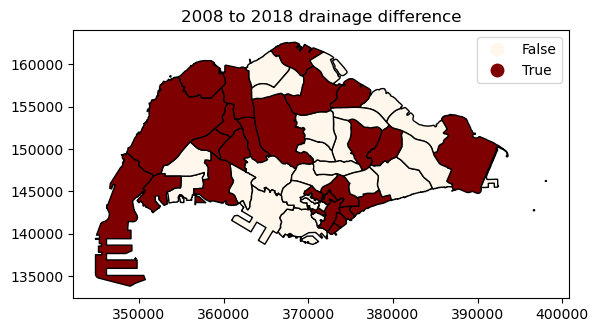

In [215]:
def drainage_density_difference(drain_before,drain_after,plot=True,ax=None,title=""):
    """    
    calculate difference in drainage density between years                         
    Args:
        drain_before (pd.DataFrame):
        drain_after (pd.DataFrame):
    """
    drain_after["drainage_density_difference"] = drain_after["drainage_density (km/km2)"] - drain_before["drainage_density (km/km2)"]
    # positive if there is an increase in drainage density, -ve if there is a decrease
    drain_after["drainage_density_direction"] = drain_after["drainage_density_difference"]>0
    if plot:
        ax = drain_after.plot(column="drainage_density_direction",cmap='OrRd',ec="k",
                               ax=ax,
                               legend=True)
        ax.set_title(title)
    return 

drainage_density_difference(year_drainage_density["2008Bluemap.shp"],
                            year_drainage_density["2018Bluemap.shp"],
                            title="2008 to 2018 drainage difference",
                            plot=True,ax=None)

# Correct completed drainage projects (2012-2024) [Analysis]

In [92]:
drainage_projects = pd.read_csv(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\Drainage plans\PUB_All_Drainage_Projects_2012_2024.csv")
drainage_projects_completed = drainage_projects[drainage_projects["Status"]=="Completed"]
drainage_projects_completed["Date"] = pd.to_datetime(drainage_projects_completed["Date"],format="%b-%y")
drainage_projects_completed["Year"] = drainage_projects_completed["Date"].dt.year
drainage_projects_completed["Month"] = drainage_projects_completed["Date"].dt.month

# separate project type and location

def extract_road_names(text):
    
    pattern = r"^(.*?)\s*(?:\bat\b|[-–—@])\s*(.*)$"

    match = re.search(pattern, text, re.IGNORECASE)
    if match:
        work_types = match.group(1).strip()
        location = match.group(2).strip()
    else:
        pattern = r"^(.*?)\s*\b(?:in|to|along|of|for)\s*(.*)$"

        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            work_types = match.group(1).strip()
            location = match.group(2).strip()
        else:
            work_types = None
            location = text
    
    return pd.Series({"work_types":work_types,"location":location},index=["work_types","location"])

drainage_projects_completed[["work_types","location"]] = drainage_projects_completed["Location"].apply(lambda x: extract_road_names(x))

# Find multiple roads and split them if applicable

def extract_multiple_road_names(text):

    # Remove extra whitespace
    text = text.strip()

    def split_separator(s):
        # Otherwise, split by common separators (/, &, to, ,)
        pattern = r'\s*(?:/|&|,|\bto\b)\s*'
        parts = re.split(pattern, s, flags=re.IGNORECASE)
        return [p.strip() for p in parts if p.strip()]
    
    # 1. Handle parentheses first — extract before and inside ()
    bracket_match = re.match(r'^(.*?)\s*\(([^)]+)\)\s*$', text)
    if bracket_match:
        before = bracket_match.group(1).strip()
        inside = bracket_match.group(2).strip()
        
        return [before] + split_separator(inside)

    return split_separator(text)

drainage_projects_completed["locations"] = drainage_projects_completed["location"].apply(lambda x: extract_multiple_road_names(x))
drainage_projects_completed = drainage_projects_completed.explode("locations")

drainage_projects_completed

C:\Users\hypak\AppData\Local\Temp\ipykernel_4724\2806663881.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drainage_projects_completed["Date"] = pd.to_datetime(drainage_projects_completed["Date"],format="%b-%y")
C:\Users\hypak\AppData\Local\Temp\ipykernel_4724\2806663881.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drainage_projects_completed["Year"] = drainage_projects_completed["Date"].dt.year
C:\Users\hypak\AppData\Local\Temp\ipykernel_4724\2806663881.py:5: SettingWithCopyWarning: 
A value is

,S/N,Location,Date,Status,Year,Month,work_types,location,locations
0,1,Development of Kallang River – Bishan-Ang Mo K...,2012-01-01,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park
1,2,Road Raising and Drainage Works at Ah Hood Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road
2,3,Road Raising and Drainage Works at Balmoral Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road
3,4,Road Raising and Drainage Works at Bedok Lane,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane
4,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden
...,...,...,...,...,...,...,...,...,...
436,437,Improvement to Roadside Drains and Watermain R...,2023-12-01,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Happy Gardens Estate
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road
438,439,Drainage work at Jurong East St 32,2023-07-01,Completed,2023,7,Drainage work,Jurong East St 32,Jurong East St 32


Get coordinates of drainage works location

In [93]:
def get_road_location(road,headers,index=['SEARCHVAL','BLK_NO','ROAD_NAME','BUILDING','ADDRESS','POSTAL','X','Y','LATITUDE','LONGITUDE']):
    try:
        searches = OneMapAPI.get_coordinates_from_location(road, headers)
        location_dict = searches[0]
        location_dict["number_of_searches"] = len(searches)
    except:
        index.append("number_of_searches")
        location_dict = {k:None for k in index}
    
    
    return pd.Series(location_dict, index=list(location_dict))

headers = OneMapAPI.generate_OneMap_headers()
drainage_locations = drainage_projects_completed["locations"].apply(lambda x: get_road_location(x,headers))
drainage_locations

,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,BISHAN - ANG MO KIO PARK (POND GARDENS),,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.5993566066,38579.1553769931,1.36517069591469,103.83629822663,2.0
1,AH HOOD ROAD,,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.5309455593,34437.90693839,1.32771861428245,103.846855352744,2.0
2,BALMORAL ROAD,,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.8432115718,32837.3066058314,1.31324355521211,103.830181342875,1.0
3,BEDOK LANE,,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.7222646378,34619.5605429257,1.32935743601885,103.948251313101,1.0
4,BEDOK RESERVOIR GARDEN,716,BEDOK RESERVOIR ROAD,BEDOK RESERVOIR GARDEN,716 BEDOK RESERVOIR ROAD BEDOK RESERVOIR GARDE...,470716,38200.2399324467,35557.0303214137,1.33783795176833,103.924973671246,10.0
...,...,...,...,...,...,...,...,...,...,...,...
436,None,None,None,None,None,None,None,None,None,None,NaN
437,KRAMAT LANE,,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.6459057741,31481.2032468384,1.30097931805497,103.84227389462,1.0
437,CAVENAGH ROAD,,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.5044461648,32268.6550906781,1.30809356579841,103.84213845629,1.0
438,JURONG EAST STREET 32,,JURONG EAST STREET 32,NIL,JURONG EAST STREET 32,NIL,16927.0841891803,36565.146363027,1.34694849545159,103.733825383102,1.0


In [94]:
drainage_projects_completed = pd.concat([drainage_projects_completed,drainage_locations],axis=1)
drainage_projects_completed.to_csv(r"Exported_Data\drainage_works_2012_2024.csv",index=False)
drainage_projects_completed

,S/N,Location,Date,Status,Year,Month,work_types,location,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,1,Development of Kallang River – Bishan-Ang Mo K...,2012-01-01,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.5993566066,38579.1553769931,1.36517069591469,103.83629822663,2.0
1,2,Road Raising and Drainage Works at Ah Hood Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.5309455593,34437.90693839,1.32771861428245,103.846855352744,2.0
2,3,Road Raising and Drainage Works at Balmoral Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.8432115718,32837.3066058314,1.31324355521211,103.830181342875,1.0
3,4,Road Raising and Drainage Works at Bedok Lane,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.7222646378,34619.5605429257,1.32935743601885,103.948251313101,1.0
4,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,BEDOK RESERVOIR GARDEN,716,BEDOK RESERVOIR ROAD,BEDOK RESERVOIR GARDEN,716 BEDOK RESERVOIR ROAD BEDOK RESERVOIR GARDE...,470716,38200.2399324467,35557.0303214137,1.33783795176833,103.924973671246,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,437,Improvement to Roadside Drains and Watermain R...,2023-12-01,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Happy Gardens Estate,None,None,None,None,None,None,None,None,None,None,NaN
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane,KRAMAT LANE,,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.6459057741,31481.2032468384,1.30097931805497,103.84227389462,1.0
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road,CAVENAGH ROAD,,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.5044461648,32268.6550906781,1.30809356579841,103.84213845629,1.0
438,439,Drainage work at Jurong East St 32,2023-07-01,Completed,2023,7,Drainage work,Jurong East St 32,Jurong East St 32,JURONG EAST STREET 32,,JURONG EAST STREET 32,NIL,JURONG EAST STREET 32,NIL,16927.0841891803,36565.146363027,1.34694849545159,103.733825383102,1.0


In [154]:
def get_location_IQ(location,
                    index=['SEARCHVAL','BLK_NO','ROAD_NAME','BUILDING','ADDRESS','POSTAL','X','Y','LATITUDE','LONGITUDE']):
    searches = LocationIqAPI.get_coordinates_from_location(location)

    location_dict = {k:None for k in index}
    try:
        response = searches[0]
        location_dict['SEARCHVAL'] = response['display_name']
        location_dict['LATITUDE'] = response['lat']
        location_dict['LONGITUDE'] = response['lon']
        location_dict["number_of_searches"] = len(searches)
    except:
        location_dict["number_of_searches"] = None
    
    return pd.Series(location_dict,index=list(location_dict))
    
    
x = get_location_IQ("Phoenix, Singapore, Singapore")
x

SEARCHVAL             Phoenix, 40, Choa Chu Kang Road, Teck Whye, Ch...
BLK_NO                                                             None
ROAD_NAME                                                          None
BUILDING                                                           None
ADDRESS                                                            None
POSTAL                                                             None
X                                                                  None
Y                                                                  None
LATITUDE                                                      1.3786164
LONGITUDE                                                    103.758008
number_of_searches                                                    2
dtype: object

In [165]:
lorongGeylang = LocationIqAPI.get_coordinates_from_location("Lorong 42 Geylang, Singapore, Singapore")
lorongGeylang

[{'place_id': '251031082',
  'licence': 'https://locationiq.com/attribution',
  'osm_type': 'way',
  'osm_id': '46342760',
  'boundingbox': ['1.3143543', '1.3146876', '103.8902132', '103.8902533'],
  'lat': '1.3146876',
  'lon': '103.8902132',
  'display_name': 'Lorong 42 Geylang, Geylang, Southeast, Singapore, 389604, Central Region, Singapore',
  'class': 'highway',
  'type': 'residential',
  'importance': 0.5834176615548942},
 {'place_id': '250993455',
  'licence': 'https://locationiq.com/attribution',
  'osm_type': 'way',
  'osm_id': '1015739635',
  'boundingbox': ['1.3140305', '1.3141815', '103.8902879', '103.8903376'],
  'lat': '1.3140473',
  'lon': '103.8903147',
  'display_name': 'Lorong 42 Geylang, Geylang, Southeast, Singapore, 398024, Central Region, Singapore',
  'class': 'highway',
  'type': 'service',
  'importance': 0.5700843282215609},
 {'place_id': '251351702',
  'licence': 'https://locationiq.com/attribution',
  'osm_type': 'way',
  'osm_id': '647095214',
  'boundingb

In [160]:
problematic_rows = drainage_projects_completed[((drainage_projects_completed['number_of_searches']>2) | (drainage_projects_completed['number_of_searches'].isna()))]
problematic_rows

,S/N,Location,Date,Status,Year,Month,work_types,location,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
4,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,BEDOK RESERVOIR GARDEN,716,BEDOK RESERVOIR ROAD,BEDOK RESERVOIR GARDEN,716 BEDOK RESERVOIR ROAD BEDOK RESERVOIR GARDE...,470716,38200.2399324467,35557.0303214137,1.33783795176833,103.924973671246,10.0
8,9,Drainage Works at Ewe Boon Rd Areas,2012-11-01,Completed,2012,11,Drainage Works,Ewe Boon Rd Areas,Ewe Boon Rd Areas,None,None,None,None,None,None,None,None,None,None,NaN
10,11,Improvement to Roadside Drains In Estate Upgra...,2012-11-01,Completed,2012,11,Improvement to Roadside Drains In Estate Upgra...,Phoenix,Phoenix,PHOENIX HEIGHTS,10,PHOENIX GARDEN,PHOENIX HEIGHTS,10 PHOENIX GARDEN PHOENIX HEIGHTS SINGAPORE 66...,668278,19662.3186762407,39840.217556119,1.37657410885303,103.758398456974,10.0
12,13,Drainage Works at Lorong 102 to 106 Changi Rd,2013-01-01,Completed,2013,1,Drainage Works,Lorong 102 to 106 Changi Rd,106 Changi Rd,1063A UPPER CHANGI ROAD NORTH SINGAPORE 507704,1063A,UPPER CHANGI ROAD NORTH,NIL,1063A UPPER CHANGI ROAD NORTH SINGAPORE 507704,507704,43773.0555428769,38628.6779148001,1.36561435805998,103.975050188576,9.0
18,19,Drainage Works at Dunearn Rd/ Hillcrest Rd jun...,2013-01-01,Completed,2013,1,Drainage Works,Dunearn Rd/ Hillcrest Rd junction,Dunearn Rd,DUNEARN ROAD / WAYANG SATU FLYOVER - ERP(43),,NIL,DUNEARN ROAD / WAYANG SATU FLYOVER - ERP(43),DUNEARN ROAD / WAYANG SATU FLYOVER - ERP(43),NIL,26907.0627031503,33764.3403379712,1.32162720092152,103.823497961309,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,431,Improvement to Bayshore Park Outlet Drain (ECP...,2023-03-01,Completed,2023,3,Improvement,Bayshore Park Outlet Drain (ECP Service Road t...,Bayshore Park Outlet Drain,None,None,None,None,None,None,None,None,None,None,NaN
430,431,Improvement to Bayshore Park Outlet Drain (ECP...,2023-03-01,Completed,2023,3,Improvement,Bayshore Park Outlet Drain (ECP Service Road t...,the Sea,CHURCH OF OUR LADY STAR OF THE SEA,10,YISHUN STREET 22,CHURCH OF OUR LADY STAR OF THE SEA,10 YISHUN STREET 22 CHURCH OF OUR LADY STAR OF...,768579,28515.1892367527,46549.7553463355,1.43725393340129,103.837948048756,10.0
433,434,Drainage work at Sennett Estate,2023-10-01,Completed,2023,10,Drainage work,Sennett Estate,Sennett Estate,SENNETT ESTATE,8,KWONG AVENUE,SENNETT ESTATE,8 KWONG AVENUE SENNETT ESTATE SINGAPORE 348882,348882,32218.0471483897,34727.6016367543,1.33033832214633,103.871220086251,10.0
436,437,Improvement to Roadside Drains and Watermain R...,2023-12-01,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Happy Gardens Estate,None,None,None,None,None,None,None,None,None,None,NaN


In [199]:
# OneMapAPI.get_coordinates_from_location("stadium cres", headers)
get_location_IQ("woodlands avenue 5, Singapore, Singapore")

SEARCHVAL             Woodlands Avenue 5, Woodgrove, Woodlands, Nort...
BLK_NO                                                             None
ROAD_NAME                                                          None
BUILDING                                                           None
ADDRESS                                                            None
POSTAL                                                             None
X                                                                  None
Y                                                                  None
LATITUDE                                                      1.4352105
LONGITUDE                                                   103.7832869
number_of_searches                                                   10
dtype: object

In [197]:
problematic_rows0 = pd.read_csv(r"Exported_Data\locations_problem.csv")
headers = OneMapAPI.generate_OneMap_headers()
problematic_rows0[['SEARCHVAL', 'BLK_NO', 'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE', 'LONGITUDE',"number_of_searches"]] = problematic_rows0["locations"].apply(lambda x: get_road_location(x,headers))
problematic_rows0.dropna(subset=["number_of_searches"]).to_csv(r"Exported_Data\drainage_works_OneMap.csv",index=False)
problematic_rows0

,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,Bukit Timah Road,BT TIMAH EXPRESSWAY (SB BETW DAIRY FARM RD & P...,,NIL,BT TIMAH EXPRESSWAY (SB BETW DAIRY FARM RD & P...,BT TIMAH EXPRESSWAY (SB BETW DAIRY FARM RD & P...,NIL,22941.8794712201,37287.9545795117,1.35349310900464,103.787868117719,10.0
1,Holland Green,HOLLAND GREEN,13,HOLLAND GREEN,HOLLAND GREEN,13 HOLLAND GREEN HOLLAND GREEN SINGAPORE 276136,276136,22560.6319996007,34204.5193922799,1.32560755852268,103.784442917855,10.0
2,Simon Lane,SIMON LANE,,SIMON LANE,NIL,SIMON LANE,NIL,33686.1137061781,38364.3591386009,1.3632275437128,103.884412113606,1.0
3,Woodlands Ave 5,WOODLANDS (AVE 5) PARK CONNECTOR,,NIL,WOODLANDS (AVE 5) PARK CONNECTOR,WOODLANDS (AVE 5) PARK CONNECTOR,NIL,22677.5393020539,46213.5384015962,1.43421281069085,103.785491223073,2.0
4,Yishun Ave 2,YISHUN AVENUE 2,,YISHUN AVENUE 2,NIL,YISHUN AVENUE 2,NIL,28202.6440075983,45273.5176599755,1.42571397983231,103.835139618109,1.0
5,Yishun Ring Rd,YISHUN RING ROAD,,YISHUN RING ROAD,NIL,YISHUN RING ROAD,NIL,27862.0939109092,45319.0557803195,1.42612719073754,103.832079231115,1.0
6,Begonia Crescent,BEGONIA CRESCENT,,BEGONIA CRESCENT,NIL,BEGONIA CRESCENT,NIL,31245.2722163482,41191.7776856891,1.38879640980153,103.862479371745,1.0
7,Tamarind Rd,TAMARIND ROAD,,TAMARIND ROAD,NIL,TAMARIND ROAD,NIL,31056.8891117251,41214.2047590209,1.38900165033246,103.860786121723,2.0
8,International Road,INTERNATIONAL ROAD,,INTERNATIONAL ROAD,NIL,INTERNATIONAL ROAD,NIL,13189.1185101493,34441.8549599852,1.32775081717739,103.700234799202,1.0
9,2nd Lok Yang Road,None,None,None,None,None,None,None,None,None,None,NaN


In [198]:
problematic_rows0 = pd.read_csv(r"Exported_Data\locations_problem.csv")
problematic_rows0[['SEARCHVAL', 'BLK_NO', 'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE', 'LONGITUDE',"number_of_searches"]] = problematic_rows0["locations"].apply(lambda x: get_location_IQ(f"{x}, Singapore, Singapore"))
problematic_rows0.dropna(subset=["number_of_searches"]).to_csv(r"Exported_Data\drainage_works_locationIQ.csv",index=False)
problematic_rows0

,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,Bukit Timah Road,"Bukit Timah Road, Fairwood Park, Bukit Timah, ...",None,None,None,None,None,None,None,1.3364318,103.7818681,10.0
1,Holland Green,"Holland Green, Ewart Park, Bukit Timah, Northw...",None,None,None,None,None,None,None,1.3259011,103.7849681,10.0
2,Simon Lane,"Simon Lane, Hougang, Singapur East, Northeast,...",None,None,None,None,None,None,None,1.363333,103.8845316,6.0
3,Woodlands Ave 5,None,None,None,None,None,None,None,None,None,None,NaN
4,Yishun Ave 2,None,None,None,None,None,None,None,None,None,None,NaN
5,Yishun Ring Rd,"Yishun Ring Road, Yishun, Northwest, Singapore...",None,None,None,None,None,None,None,1.4179201,103.8403973,10.0
6,Begonia Crescent,"Begonia Crescent, Serangoon, Hock Swee Hill, C...",None,None,None,None,None,None,None,1.3893102,103.8626113,2.0
7,Tamarind Rd,None,None,None,None,None,None,None,None,None,None,NaN
8,International Road,"International Road, Jurong West, Southwest, Si...",None,None,None,None,None,None,None,1.3278187,103.6878477,10.0
9,2nd Lok Yang Road,"90, Second Lok Yang Road, Joo Koon, Pioneer, S...",None,None,None,None,None,None,None,1.32558,103.691185,10.0
